# Multimodal MCI Diagnosis & Stability Prediction

**Thesis demonstration** — End-to-end inference pipeline for two real patients using all
pre-trained models: Chandra OCR, Mistral LLM, MRI 3D-CNN, PET 3D-CNN,
LightGBM diagnosis, neural ensemble diagnosis, RNN stability, LightGBM stability.

> **No training occurs in this notebook.** All weights are loaded from locally saved files.

## Environment Setup

Imports all required libraries and defines all file paths for models, images, and data files.
This cell must run first — every subsequent cell depends on these definitions.

In [1]:
import sys, warnings, pickle, os, json, re, time
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

pd.set_option('display.max_columns', None)
BASE_DIR = Path("/kaggle/input/datasets/baraafzlalagui/demo-fyp-data-and-models/kaggle_dataset")

# -- Model and image paths ------------------------------------------------
MRI_IMAGE_DIR = BASE_DIR / "mri" / "images"   # already-preprocessed fallback scans
MRI_RAW_DIR   = BASE_DIR / "mri" / "raw"       # raw scans, run through real preprocessing
MRI_FOLD_DIR  = BASE_DIR / "mri" / "models"

PET_IMAGE_DIR     = BASE_DIR / "pet" / "images"             # already-preprocessed fallback scans
PET_RAW_DIR       = BASE_DIR / "pet" / "raw"                 # raw scans, run through real preprocessing
PET_PREPROC_DIR   = BASE_DIR / "pet" / "preproc_artifacts"   # FBP template / brain mask / cerebellum mask
PET_FOLD_DIR      = BASE_DIR / "pet" / "models"

DIAG_ROOT    = BASE_DIR / "diagnosis_alg"
STAB_ROOT    = BASE_DIR / "stability_alg"
PROMPT_DIR   = BASE_DIR / "prompt"

# -- PET age normalisation (training-set-wide statistics, not patient-specific) --
PET_AGE_MEAN = 75.072048
PET_AGE_STD  =  7.961197

# -- Demo patients --------------------------------------------------------
# mri_sub / pet_sub = None means that patient has no imaging scan.
# Scans belong to whichever patient actually has them in their own folder:
# Patient B's folder contains her own MRI/PET scans; Patient A has none.
PATIENTS = [
    {"folder": str(BASE_DIR / "patients" / "patient_mci"),          "label": "Patient A",
     "mri_sub": None,        "pet_sub": None},
    {"folder": str(BASE_DIR / "patients" / "patient_mci_unstable"), "label": "Patient B",
     "mri_sub": "1266992",  "pet_sub": "I305639"},
]

print("All paths configured.")

Device  : cuda
PyTorch : 2.10.0+cu128
All paths configured.


## Patient Reports — Scanned Handwritten Clinical Notes

Displays the raw scanned pages for each patient. These are the inputs to the OCR step.
Patient A's report is expected to reflect a stable MCI profile; Patient B's an unstable one.

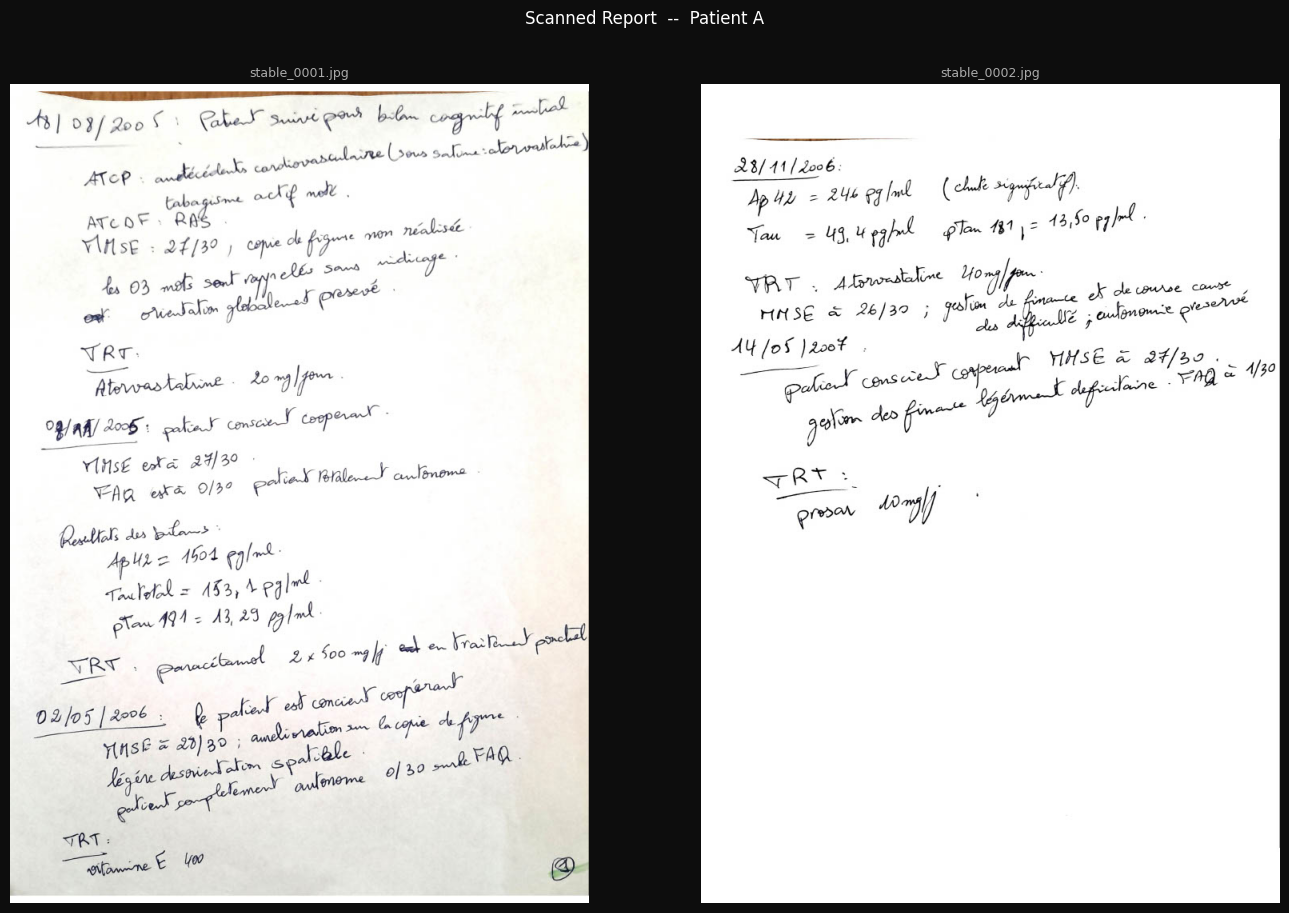

  Patient A: 2 page(s)  --  ['stable_0001.jpg', 'stable_0002.jpg']


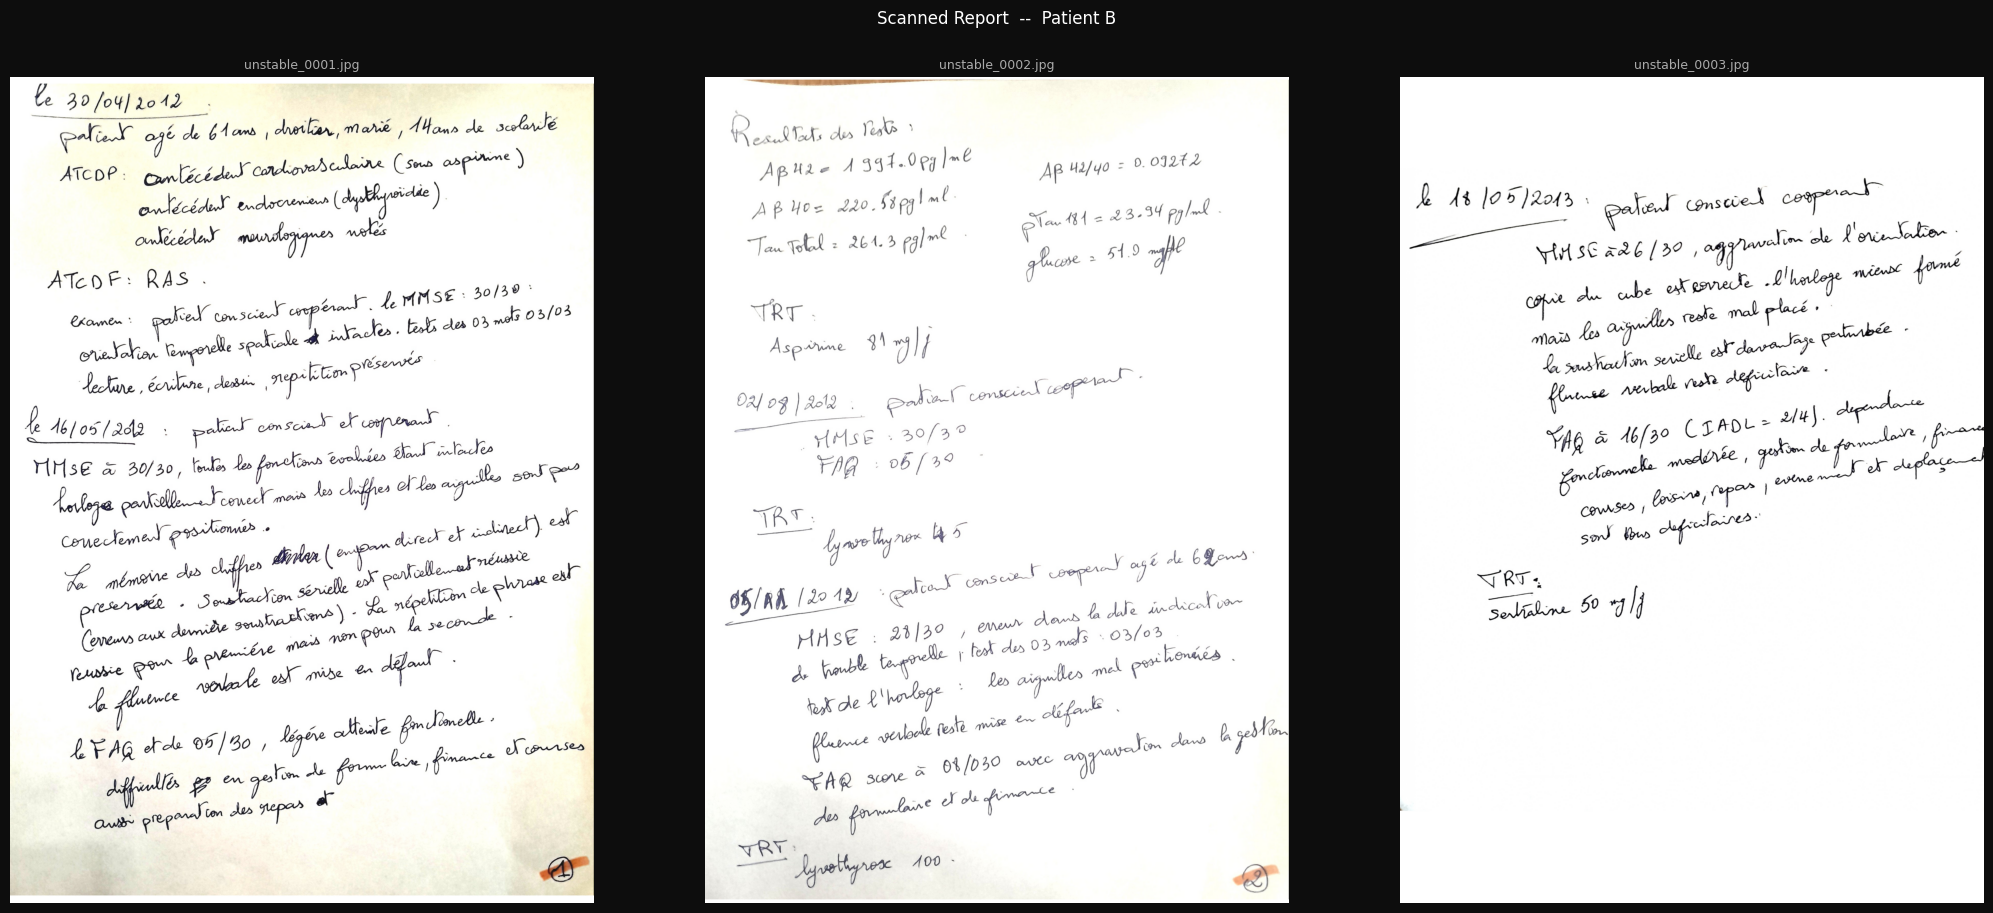

  Patient B: 3 page(s)  --  ['unstable_0001.jpg', 'unstable_0002.jpg', 'unstable_0003.jpg']


In [2]:
# Display the scanned handwritten clinical reports for each patient
for pat in PATIENTS:
    folder = pat["folder"]
    label  = pat["label"]
    pages  = sorted(
        [f for f in Path(folder).iterdir()
         if f.suffix.lower() in {".jpg", ".jpeg", ".png"}],
        key=lambda p: p.name,
    )
    n = len(pages)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 9), facecolor='#0d0d0d')
    if n == 1:
        axes = [axes]
    for ax, img_path in zip(axes, pages):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(img_path.name, color='#aaaaaa', fontsize=9, pad=6)
        ax.axis('off')
    fig.suptitle(f"Scanned Report  --  {label}", color='white', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"  {label}: {n} page(s)  --  {[p.name for p in pages]}")


## Step 1a — Install OCR Package

Installs `chandra-ocr` (Chandra VLM, `datalab-to/chandra-ocr-2`) and `pyspellchecker`.
On Kaggle, this runs once at session start. Safe to skip if already installed.

In [3]:
# ── Install Chandra OCR ───────────────────────────────────────────────────────
import subprocess, sys

print("Installing Chandra OCR (datalab-to/chandra-ocr-2) ...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "chandra-ocr[hf]"])
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyspellchecker"])

import torch
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch        : {torch.__version__}")


Installing Chandra OCR (datalab-to/chandra-ocr-2) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 115.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 97.8 MB/s eta 0:00:00
CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB
PyTorch        : 2.10.0+cu128


## Step 1b — Load Chandra OCR Model

Downloads and loads the Chandra vision-language model in `bfloat16` onto the GPU.
This model reads the handwritten scanned report pages and returns structured text.

In [4]:
# ── Load Chandra OCR model ───────────────────────────────────────────────────
from transformers import AutoModelForImageTextToText, AutoProcessor
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown
from PIL import Image

print("Loading Chandra OCR on GPU (bfloat16)...")
chandra_model = AutoModelForImageTextToText.from_pretrained(
    "datalab-to/chandra-ocr-2",
    dtype=torch.bfloat16,
    device_map="auto",
)
chandra_model.eval()
chandra_model.processor = AutoProcessor.from_pretrained("datalab-to/chandra-ocr-2")
chandra_model.processor.tokenizer.padding_side = "left"

print("✓ Chandra OCR loaded")
if torch.cuda.is_available():
    print(f"  VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")


Loading Chandra OCR on GPU (bfloat16)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/10.6G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/724 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

✓ Chandra OCR loaded
  VRAM used: 4.41 GB


## Step 1c — OCR Inference Helpers

Defines `ocr_report(folder)` which iterates over all page images in a patient folder,
runs Chandra OCR on each, and concatenates the raw text output.
Also defines image loading and resizing utilities used by the OCR call.

In [5]:
# -- Clinical report OCR helpers --
import re
from pathlib import Path

MAX_IMAGE_DIM = 1536
IMAGE_EXTS    = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}


def _natural_key(path: Path):
    return [int(tok) if tok.isdigit() else tok.lower()
            for tok in re.split(r'(\d+)', path.stem)]


def _list_report_pages(path: str) -> list:
    p = Path(path)
    if p.is_file():
        return [p]
    pages = sorted((f for f in p.iterdir() if f.suffix.lower() in IMAGE_EXTS),
                   key=_natural_key)
    if not pages:
        raise FileNotFoundError(f"No image files found in {p}")
    return pages


def _resize_for_chandra(img: Image.Image, max_dim: int = MAX_IMAGE_DIM) -> Image.Image:
    w, h = img.size
    longest = max(w, h)
    if longest <= max_dim:
        return img
    scale = max_dim / longest
    return img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.LANCZOS)


def _markdown_to_lines(raw_markdown: str) -> str:
    markdown = parse_markdown(raw_markdown)
    lines = []
    for line in markdown.splitlines():
        line = re.sub(r'^#+\s*', '', line.strip())
        line = re.sub(r'^[-*•]\s*', '', line)
        if line:
            lines.append(line)
    return ' '.join(lines)


def run_chandra_ocr(image_path) -> str:
    img = Image.open(image_path).convert("RGB")
    img = _resize_for_chandra(img)
    batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
    try:
        result = generate_hf(batch, chandra_model)[0]
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        img = _resize_for_chandra(img, max_dim=MAX_IMAGE_DIM // 2)
        batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
        result = generate_hf(batch, chandra_model)[0]
    return _markdown_to_lines(result.raw)


def ocr_report(folder: str) -> str:
    """Run Chandra OCR on all pages in folder, return concatenated raw text."""
    pages = _list_report_pages(folder)
    print(f"  Found {len(pages)} page(s): {[p.name for p in pages]}")
    texts = []
    for i, page_path in enumerate(pages, 1):
        print(f"  Page {i}/{len(pages)}: {page_path.name} ...", end=" ", flush=True)
        texts.append(run_chandra_ocr(page_path))
        print("done")
    return "\n".join(texts)


print("OCR helper functions defined.")

OCR helper functions defined.


## Step 3a — Install Mistral Client

Installs the `mistralai` Python package. Required to call the Mistral Large API.
On Kaggle, add your `MISTRAL_API_KEY` under Settings > Add-ons > Secrets.

In [6]:
# ── Install Mistral client ────────────────────────────────────────────────────
!pip install -q mistralai
print("mistralai ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.
mistralai ready.


## Step 3b — LLM Feature Extraction: Longitudinal ADNI Table Builder

Defines the full extraction pipeline that converts raw French clinical text
into a real longitudinal ADNI table — one row per visit actually documented in
the report, instead of a single consolidated record:

- **`TARGET_COLUMNS`**: the ADNI fields extracted for every visit
- **`CODEBOOK`**: data dictionary with ADNI categorical encodings, loaded from
  `prompt/codebook.txt`
- **`SYSTEM_PROMPT`**: loaded from `prompt/system_prompt.txt` and filled in with
  the codebook + target columns; instructs Mistral to segment the report into
  distinct visits, treating persistent patient facts (demographics, medical/family
  history) as constant across visits while keeping time-varying test scores strictly
  per-visit
- **`call_mistral_visits(text)`**: sends the report to `mistral-large-latest` with
  `temperature=0` and `response_format=json_object`, returns `visits_list`

Also loads the Mistral client using `MISTRAL_API_KEY` from the environment.

In [7]:
# ── Mistral API setup ─────────────────────────────────────────────────────────
import os, json, re, time
from mistralai.client import Mistral

mistral_client = Mistral(api_key='KtOiDeqkk3RpPlftZZ6wAzi0W3SgwIIp')

# ── Target columns ─────────────────────────────────────────────────────────────
TARGET_COLUMNS = [
    # Patient demographics
    "age", "PTGENDER", "PTEDUCAT", "PTHAND", "PTMARRY", "PTNOTRT", "PTWORK",
    # Visit identification
    "VISDATE",
    # MMSE sub-items
    "MMDATE","MMYEAR","MMMONTH","MMDAY",
    "MMREAD","MMWRITE","MMDRAW","MMREPEAT",
    "MMSEASON","MMHOSPIT","MMFLOOR","MMCITY",
    "WORD1","WORD2","WORD3","MMSCORE",
    # MoCA / Clock
    "MOCA","CUBE","CLOCKCON","CLOCKNO","CLOCKHAN",
    # Digit span / Serial 7 / Repetition / Fluency
    "DIGFOR","DIGBACK",
    "SERIAL1","SERIAL2","SERIAL3","SERIAL4","SERIAL5",
    "REPEAT1","REPEAT2","FFLUENCY",
    # FAQ
    "FAQFORM","FAQFINAN","FAQSHOP","FAQGAME","FAQBEVG",
    "FAQMEAL","FAQEVENT","FAQTV","FAQREM","FAQTRAVL","FAQ",
    # Blood biomarkers (available in Algerian clinical setting)
    "Abeta42","Abeta40","Abeta_ratio",
    "Tau181","pTau181",
    "Calcium","Creatinine","Direct Bilirubin",
    "Gamma-Glutamyltransferase",
    "Hematocrit","Hemoglobin","Hemoglobin A1C",
    "Homocysteine",
    "Platelet Ct.","Red Blood Cell Count",
    "Thyroid-stimulating hormone","Total Bilirubin",
    "Vitamin B12","White Blood Cell Count",
    "glucose",
    # Family history
    "MOTHDEM","MOTHAD","MOTHSXAGE",
    "FATHDEM","FATHAD","FATHSXAGE",
    "SIBGENDER","SIBDEMENT","SIBAD","SIBSXAGE",
    # Intercurrent illness
    "IHSYMPTOM","IHDESC","IHCHRON","IHSEVER","IHPRESENT","IHSURG",
    # Medical history flags
    "MH19OTHR","MHPSYCH","MH2NEURL","MH3HEAD","MH4CARD",
    "MH5RESP","MH6HEPAT","MH7DERM","MH8MUSCL","MH9ENDO",
    "MH14BALCH","MH14CALCH","MH10GAST","MH11HEMA","MH12RENA",
    "MH13ALLE","MH14ALCH","MH14AALCH","MH17MALI","MH18SURG",
    # Substance history
    "MH15DRUG","MH15ADRUG","MH15BDRUG",
    "MH16SMOK","MH16ASMOK","MH16BSMOK","MH16CSMOK",
    # Behavioural symptoms
    "BSXSYMNO","BSXSEVER","BSXCHRON",
    # Medication
    "KEYMED","CMMED","CMDOSE","CMREASON",
]

# ── ADNI codebook + system prompt, loaded from text files ──────────────────────
CODEBOOK = (PROMPT_DIR / "codebook.txt").read_text(encoding="utf-8")

_system_prompt_template = (PROMPT_DIR / "system_prompt.txt").read_text(encoding="utf-8")
SYSTEM_PROMPT = (
    _system_prompt_template
    .replace("{{CODEBOOK}}", CODEBOOK)
    .replace("{{TARGET_COLUMNS}}", json.dumps(TARGET_COLUMNS, ensure_ascii=False))
)


def build_user_prompt(text: str) -> str:
    return (
        "Patient clinical report (French), may cover one or several visits over time:\n"
        "---\n"
        f"{text}\n"
        "---\n"
        "Identify every distinct visit documented in this report and extract the ADNI "
        "values for each one, returning the {visits:[...]} JSON object described "
        "in the system prompt."
    )


def call_mistral_visits(text: str, retries: int = 3) -> list:
    """Extract every visit documented in the report. Returns visits_list."""
    for attempt in range(retries):
        try:
            response = mistral_client.chat.complete(
                model="mistral-large-latest",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": build_user_prompt(text)},
                ],
                temperature=0.0,
                response_format={"type": "json_object"},
            )
            raw = response.choices[0].message.content.strip()
            raw = re.sub(r'^```(?:json)?\s*', '', raw)
            raw = re.sub(r'\s*```$', '', raw)
            parsed = json.loads(raw)
            visits = parsed.get("visits") or []
            if not visits:
                print(f"  [attempt {attempt + 1}] No visits returned, retrying ...")
                continue
            return visits
        except Exception as e:
            print(f"  [attempt {attempt + 1}] Error: {e}")
            if attempt < retries - 1:
                time.sleep(3)
    return []



print("Mistral client and helpers defined.")


Mistral client and helpers defined.


## Step 4a — MRI Model Architecture

Defines `Small3DCNNDemo`, the 3D convolutional architecture trained to detect
medial temporal atrophy (MTA) from preprocessed T1-weighted MRI volumes.
The model fuses a demographic branch (age, sex, education) with the CNN backbone.
`CHANNEL_CONFIGS` maps the fold-specific channel keys from the saved checkpoints.

In [8]:
# ── MRI model architecture (must match training) ─────────────────────────────
class Small3DCNNDemo(nn.Module):
    def __init__(self, n_demo_features=3, demo_hidden=16,
                 n_targets=1, dropout=0.3, channels=(16, 32, 64, 128)):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm3d(out_c), nn.ReLU(inplace=True), nn.MaxPool3d(2))
        layers = [block(1, channels[0])]
        for i in range(len(channels) - 1):
            layers.append(block(channels[i], channels[i + 1]))
        self.backbone     = nn.Sequential(*layers)
        self.global_pool  = nn.AdaptiveAvgPool3d(1)
        self.demo_encoder = nn.Sequential(
            nn.Linear(n_demo_features, demo_hidden), nn.ReLU(inplace=True),
            nn.Linear(demo_hidden, demo_hidden),     nn.ReLU(inplace=True))
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(channels[-1] + demo_hidden, n_targets)

    def forward(self, x, demo):
        feat = self.global_pool(self.backbone(x)).flatten(1)
        d    = self.demo_encoder(demo)
        return self.head(self.dropout(torch.cat([feat, d], dim=1))).squeeze(1)

CHANNEL_CONFIGS = {
    "narrow_3":   (8,  16,  32),
    "narrow_4":   (8,  16,  32,  64),
    "standard_4": (16, 32,  64, 128),
    "wide_4":     (32, 64, 128, 256),
}
print("Small3DCNNDemo architecture loaded.")


Small3DCNNDemo architecture loaded.


## Step 4b — MRI 7-Fold Ensemble Inference

Defines `infer_mri(volume, subject_id)` which runs the 7-fold cross-validation
ensemble. For each fold it loads the per-fold scaler and config from `fold_k.pkl`,
reconstructs the model, and runs a forward pass. The final atrophy decision is
the average probability across all 7 folds compared to the average threshold.

In [9]:
# -- MRI 7-fold ensemble inference function --
def infer_mri(mri_vol: np.ndarray, age: float, gender: float, edu: float):
    """Run the 7-fold MRI atrophy ensemble. Returns (atrophy_flag, avg_prob, avg_thr).
    gender: 1.0=Male, 0.0=Female  (training convention)
    """
    x = torch.from_numpy(mri_vol[None, None]).to(DEVICE)
    probs, thrs = [], []
    for k in range(7):
        with open(MRI_FOLD_DIR / f"fold_{k}.pkl", "rb") as f:
            res = pickle.load(f)
        sc  = res["demo_scaler"]
        cfg = res["config"]
        thr = res["test_results"]["threshold"]
        age_z = (age - sc["age_mean"]) / sc["age_std"]
        edu_z = (edu - sc["edu_mean"]) / sc["edu_std"]
        demo  = torch.tensor([[gender, age_z, edu_z]], dtype=torch.float32).to(DEVICE)
        m = Small3DCNNDemo(channels=CHANNEL_CONFIGS[cfg["channels_key"]],
                           demo_hidden=cfg["demo_hidden"], dropout=cfg["dropout"]).to(DEVICE)
        m.load_state_dict(torch.load(MRI_FOLD_DIR / f"fold_{k}_best_model.pt",
                                     map_location=DEVICE, weights_only=True))
        m.eval()
        with torch.no_grad():
            p = torch.sigmoid(m(x, demo)).item()
        probs.append(p)
        thrs.append(thr)
        del m
    avg = float(np.mean(probs))
    thr_avg = float(np.mean(thrs))
    return int(avg >= thr_avg), avg, thr_avg


print("MRI inference function defined.")

MRI inference function defined.


## MRI Raw Preprocessing — N4 + HD-BET + ANTs Registration

For a patient whose raw (unprocessed) scan is available, this defines `preprocess_mri_raw(input_path)`, the real preprocessing pipeline used to turn a raw T1w NIfTI into the (96, 96, 96) z-scored, skull-stripped, MNI-registered volume the atrophy model expects: N4 bias-field correction → HD-BET skull stripping (GPU) → affine registration to MNI152 → resample → z-score normalize.

In [10]:
# -- Install HD-BET (skull stripping) + ANTsPy (registration) --
!pip install hd-bet --quiet
!pip install antspyx --quiet


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.1/293.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━

In [11]:
# -- Raw MRI preprocessing pipeline --
def preprocess_mri_raw(input_path, target_shape=(96, 96, 96)):
    """N4 bias correction -> HD-BET skull strip -> affine registration to MNI152
    -> resample to target_shape -> z-score normalise within the brain mask.
    Returns a float32 array matching what infer_mri expects."""
    import ants, subprocess, tempfile, os
    from pathlib import Path

    try:
        mni = ants.image_read(ants.get_ants_data("mni"))
    except Exception:
        mni = ants.image_read(ants.get_data("mni"))

    img    = ants.image_read(str(input_path))
    img_n4 = ants.n4_bias_field_correction(img, shrink_factor=8,
                                            convergence={"iters": [30, 20], "tol": 1e-4})

    with tempfile.TemporaryDirectory() as tmp:
        in_path  = Path(tmp) / "in.nii"
        out_path = Path(tmp) / "brain.nii"
        ants.image_write(img_n4, str(in_path))
        device = "cuda" if torch.cuda.is_available() else "cpu"
        subprocess.run(["hd-bet", "-i", str(in_path), "-o", str(out_path),
                         "-device", device, "--save_bet_mask"],
                        check=True, env={**os.environ, "MPLBACKEND": "agg"})
        mask_path = Path(tmp) / "brain_bet.nii"
        if not mask_path.exists():
            mask_path = Path(tmp) / "brain_mask.nii"
        brain_arr = ants.image_read(str(out_path)).numpy()
        mask_arr  = ants.image_read(str(mask_path)).numpy()

    img_brain  = ants.from_numpy(brain_arr, origin=img_n4.origin,
                                  spacing=img_n4.spacing, direction=img_n4.direction)
    brain_mask = ants.from_numpy(mask_arr,  origin=img_n4.origin,
                                  spacing=img_n4.spacing, direction=img_n4.direction)

    reg      = ants.registration(fixed=mni, moving=img_brain, type_of_transform="Affine")
    img_mni  = reg["warpedmovout"]
    mask_mni = ants.apply_transforms(fixed=mni, moving=brain_mask,
                                      transformlist=reg["fwdtransforms"],
                                      interpolator="nearestNeighbor")

    img_small  = ants.resample_image(img_mni,  target_shape, use_voxels=True, interp_type=4)
    mask_small = ants.resample_image(mask_mni, target_shape, use_voxels=True, interp_type=1)

    arr = img_small.numpy()
    m   = mask_small.numpy() > 0.5
    lo, hi = np.percentile(arr[m], [1, 99])
    arr = np.clip(arr, lo, hi)
    mean, std = arr[m].mean(), arr[m].std()
    arr = ((arr - mean) / (std + 1e-8)) * m
    return arr.astype(np.float32)


print("preprocess_mri_raw defined.")


preprocess_mri_raw defined.


## Step 5a — PET Model Architecture

Defines `Simple3DCNN_LateFusion`, the 3D CNN for amyloid PET binary classification.
A late-fusion demographic branch (age, sex) is concatenated with the CNN features
before the final classification head. `PET_CFG` holds the exact hyperparameters
used at training time and stored in the saved checkpoint files.

In [12]:
# ── PET model architecture (must match training) ─────────────────────────────
class Simple3DCNN_LateFusion(nn.Module):
    def __init__(self, channels=(32,64,128,256), fc_units=128,
                 dropout=0.3, kernel_size=3, demo_hidden=16):
        super().__init__()
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks += [nn.Conv3d(in_ch, out_ch, kernel_size, padding=kernel_size//2, bias=False),
                       nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True), nn.MaxPool3d(2)]
            in_ch = out_ch
        self.encoder     = nn.Sequential(*blocks)
        self.gap         = nn.AdaptiveAvgPool3d(1)
        self.demo_branch = nn.Sequential(nn.Linear(2, demo_hidden), nn.ReLU())
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(in_ch + demo_hidden, fc_units)
        self.head        = nn.Linear(fc_units, 2)

    def forward(self, img, demo):
        x = self.gap(self.encoder(img)).flatten(1)
        x = self.dropout(torch.cat([x, self.demo_branch(demo)], dim=1))
        return self.head(F.relu(self.fc(x)))

PET_CFG = {"channels": (32, 64, 128, 256), "kernel_size": 3,
           "fc_units": 128, "dropout": 0.3, "demo_hidden": 16}
print("Simple3DCNN_LateFusion architecture loaded.")


Simple3DCNN_LateFusion architecture loaded.


## Step 5b — PET 7-Fold Ensemble Inference

Defines `infer_pet(volume, subject_id)` which runs the 7-fold amyloid PET ensemble.
Each fold checkpoint stores the best classification threshold; the final decision
averages probabilities and thresholds across all 7 folds.

In [13]:
# -- PET 7-fold ensemble inference function --
def infer_pet(pet_vol: np.ndarray, age: float, sex_f: float):
    """Run the 7-fold PET amyloid ensemble. Returns (amyloid_flag, avg_prob, avg_thr).
    sex_f: 1.0=Female, 0.0=Male  (training convention)
    """
    age_z = (age - PET_AGE_MEAN) / PET_AGE_STD
    demo  = torch.tensor([[age_z, sex_f]], dtype=torch.float32).to(DEVICE)
    x     = torch.from_numpy(pet_vol).unsqueeze(0).unsqueeze(0).to(DEVICE)
    probs, thrs = [], []
    for k in range(7):
        ckpt = torch.load(PET_FOLD_DIR / f"fold_{k}.pt", map_location=DEVICE, weights_only=False)
        m = Simple3DCNN_LateFusion(**PET_CFG).to(DEVICE)
        m.load_state_dict(ckpt["state_dict"])
        m.eval()
        with torch.no_grad():
            p = torch.softmax(m(x, demo), dim=1)[0, 1].item()
        probs.append(p)
        thrs.append(ckpt["best_threshold"])
        del m
    avg = float(np.mean(probs))
    thr_avg = float(np.mean(thrs))
    return int(avg >= thr_avg), avg, thr_avg


print("PET inference function defined.")

PET inference function defined.


## PET Raw Preprocessing — Smoothing + SyN Registration + SUVR

For a patient whose raw (unprocessed) PET scan is available, this defines `preprocess_pet_raw(input_path)`: 4mm FWHM Gaussian smoothing → SyN registration to the FBP template → cerebellar-referenced SUVR normalisation, using the template/brain-mask/cerebellum-mask artifacts shipped in `pet/preproc_artifacts/`.

In [14]:
# -- Install ANTsPy (registration) --
!pip install antspyx --quiet


In [15]:
# -- Raw PET preprocessing pipeline --
def preprocess_pet_raw(input_path):
    """Gaussian smooth -> SyN registration to the FBP template -> brain mask ->
    cerebellar-referenced SUVR normalisation. Returns a float32 array matching
    what infer_pet expects."""
    import ants, nibabel as nib
    from scipy.ndimage import gaussian_filter

    template   = np.load(PET_PREPROC_DIR / "_pp_template.npy")
    mask       = np.load(PET_PREPROC_DIR / "_pp_mask.npy").astype(bool)
    cereb_mask = np.load(PET_PREPROC_DIR / "_pp_cereb.npy").astype(bool)
    mni        = ants.image_read(ants.get_ants_data("mni"))

    img = nib.load(str(input_path))
    vox = img.header.get_zooms()[:3]
    sigma = [(4.0 / 2.355) / s for s in vox]
    smoothed = gaussian_filter(img.get_fdata().astype(np.float32), sigma)

    template_ants = ants.from_numpy(template, origin=mni.origin,
                                     spacing=mni.spacing, direction=mni.direction)
    moving = ants.from_numpy(smoothed, spacing=tuple(float(s) for s in vox))

    reg        = ants.registration(fixed=template_ants, moving=moving, type_of_transform="SyN")
    registered = reg["warpedmovout"].numpy().astype(np.float32)

    masked     = registered * mask.astype(np.float32)
    cereb_mean = masked[cereb_mask].mean()
    suvr       = (masked / cereb_mean).astype(np.float32)
    return suvr


print("preprocess_pet_raw defined.")


preprocess_pet_raw defined.


## Step 7a — Load Diagnosis Model Artifacts

Loads all pre-trained diagnosis classifier artifacts from the local model directory:
scaler, label encoder, feature columns, global medians for imputation,
string encoders for categorical features, the LightGBM model, and the ensemble
weights for the three-model neural soft-vote.

In [16]:
# -- Load all diagnosis classifier artifacts from local model directory --
diag_arts = {
    "scaler":           joblib.load(DIAG_ROOT / "scaler.pkl"),
    "label_encoder":    joblib.load(DIAG_ROOT / "label_encoder.pkl"),
    "feature_cols":     joblib.load(DIAG_ROOT / "feature_cols.pkl"),
    "global_medians":   joblib.load(DIAG_ROOT / "global_medians.pkl"),
    "string_encoders":  joblib.load(DIAG_ROOT / "string_encoders.pkl"),
    "lightgbm":         joblib.load(DIAG_ROOT / "lightgbm.pkl"),
    "ensemble_weights": joblib.load(DIAG_ROOT / "ensemble_weights.pkl"),
}

DIAG_LABELS = {0: "CN", 1: "Dementia", 2: "MCI"}

print(f"Diagnosis artifacts loaded.")
print(f"  Feature columns : {len(diag_arts['feature_cols'])}")
print(f"  Ensemble members: {list(diag_arts['ensemble_weights'].keys())}")
print(f"  Classes         : {list(diag_arts['label_encoder'].classes_)}")


Diagnosis artifacts loaded.
  Feature columns : 222
  Ensemble members: ['GRNNet', 'DeepResNet-SE', 'DualStreamDomainNet']
  Classes         : [np.int64(0), np.int64(1), np.int64(2)]


## Step 7b — Neural Ensemble: Architectures and Weights

Defines the three neural classifiers used in the diagnosis ensemble:

- **GRNNet** (Gated Residual Network, 5 blocks, hidden=256)
- **DeepResNet-SE** (6 residual blocks with squeeze-excitation, hidden=256)
- **DualStreamDomainNet** (domain-grouped dual-stream + multi-head attention)

Loads saved weights (`*_state.pt`) for all three models and defines
`predict_diag_ensemble()` which performs weighted soft-vote across them.

In [17]:
# -- Neural ensemble: architecture definitions + model loading --

# --- GRNNet ---
class GRNBlock(nn.Module):
    def __init__(self, in_d, hidden_d, out_d, dropout=0.2):
        super().__init__()
        self.fc1  = nn.Linear(in_d, hidden_d); self.fc2 = nn.Linear(hidden_d, out_d)
        self.fc3  = nn.Linear(in_d, out_d, bias=False)
        self.gate = nn.Linear(in_d, out_d)
        self.bn   = nn.BatchNorm1d(out_d); self.drop = nn.Dropout(dropout)
        self.skip = nn.Linear(in_d, out_d, bias=False) if in_d != out_d else nn.Identity()
    def forward(self, x):
        h = F.elu(self.fc1(x)); h = self.drop(h)
        h = self.fc2(h) + self.fc3(x)
        g = torch.sigmoid(self.gate(x))
        return self.bn(g * h + (1 - g) * self.skip(x))

class GRNNet(nn.Module):
    def __init__(self, n_features, hidden=256, n_blocks=5, dropout=0.25, proj_dim=64, n_out=3):
        super().__init__()
        self.entry  = nn.Sequential(nn.Linear(n_features, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.blocks     = nn.ModuleList([GRNBlock(hidden, hidden*2, hidden,
                                                   max(0.05, dropout - i*0.03)) for i in range(n_blocks)])
        self.projector  = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, proj_dim))
        self.head       = nn.Sequential(nn.Linear(hidden, 64), nn.LayerNorm(64), nn.GELU(),
                                        nn.Dropout(dropout*0.5), nn.Linear(64, n_out))
    def forward(self, x):
        x = self.entry(x)
        for b in self.blocks: x = b(x)
        return self.head(x)

# --- DeepResNet-SE ---
class SEBlock(nn.Module):
    def __init__(self, dim, reduction=4):
        super().__init__()
        self.se = nn.Sequential(nn.Linear(dim, dim//reduction), nn.ReLU(),
                                 nn.Linear(dim//reduction, dim), nn.Sigmoid())
    def forward(self, x): return x * self.se(x)

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim*2), nn.BatchNorm1d(dim*2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*2, dim), nn.BatchNorm1d(dim))
        self.se  = SEBlock(dim); self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.se(self.block(x)))

class DeepResNet(nn.Module):
    def __init__(self, n_features, hidden=256, n_blocks=6, dropout=0.25, proj_dim=64, n_out=3):
        super().__init__()
        self.entry  = nn.Sequential(nn.Linear(n_features, hidden), nn.BatchNorm1d(hidden), nn.GELU())
        self.blocks    = nn.ModuleList([ResBlock(hidden, max(0.05, dropout - i*0.025))
                                        for i in range(n_blocks)])
        self.projector = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, proj_dim))
        self.head      = nn.Sequential(nn.Linear(hidden, 64), nn.LayerNorm(64), nn.GELU(),
                                       nn.Dropout(dropout*0.4), nn.Linear(64, n_out))
    def forward(self, x):
        x = self.entry(x)
        for b in self.blocks: x = b(x)
        return self.head(x)

# --- DualStreamDomainNet ---
class DualStreamBranch(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.25):
        super().__init__()
        wide_d    = out_dim * 3
        self.wide = nn.Sequential(
            nn.Linear(in_dim, wide_d), nn.BatchNorm1d(wide_d), nn.GELU(),
            nn.Dropout(dropout*0.5), nn.Linear(wide_d, out_dim), nn.BatchNorm1d(out_dim))
        self.entry = nn.Linear(in_dim, out_dim)
        self.res1  = nn.Sequential(nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(),
                                   nn.Dropout(dropout), nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim))
        self.res2  = nn.Sequential(nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(),
                                   nn.Dropout(dropout*0.6), nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim))
        self.act      = nn.GELU()
        self.gate_in  = nn.Sequential(nn.Linear(in_dim, in_dim), nn.Sigmoid())
        self.fuse     = nn.Sequential(nn.Linear(out_dim*2, out_dim), nn.Sigmoid())
    def forward(self, x):
        xg = x * self.gate_in(x); hw = self.wide(xg)
        hd = self.act(self.entry(xg)); hd = self.act(hd + self.res1(hd)); hd = self.act(hd + self.res2(hd))
        alpha = self.fuse(torch.cat([hw, hd], dim=1))
        return alpha * hw + (1 - alpha) * hd

class DualStreamDomainNet(nn.Module):
    def __init__(self, domain_indices, branch_dim=64, n_heads=4, dropout=0.25, proj_dim=64, n_out=3):
        super().__init__()
        self.idx      = domain_indices
        self.branches = nn.ModuleDict({n: DualStreamBranch(len(ids), branch_dim, dropout)
                                        for n, ids in domain_indices.items()})
        self.norm1 = nn.LayerNorm(branch_dim)
        self.attn  = nn.MultiheadAttention(branch_dim, n_heads, dropout=0.1, batch_first=True)
        self.norm2 = nn.LayerNorm(branch_dim)
        self.ff    = nn.Sequential(nn.Linear(branch_dim, branch_dim*2), nn.GELU(),
                                   nn.Dropout(0.1), nn.Linear(branch_dim*2, branch_dim))
        pool_dim       = branch_dim * 2
        self.projector = nn.Sequential(nn.Linear(pool_dim, pool_dim), nn.GELU(), nn.Linear(pool_dim, proj_dim))
        self.head      = nn.Sequential(nn.Linear(pool_dim, 128), nn.LayerNorm(128), nn.GELU(),
                                       nn.Dropout(dropout*0.5),
                                       nn.Linear(128, 64), nn.GELU(), nn.Dropout(dropout*0.2),
                                       nn.Linear(64, n_out))
    def _pool(self, x):
        outs = [self.branches[n](x[:, self.idx[n]]) for n in self.branches]
        h    = torch.stack(outs, dim=1)
        h    = h + self.attn(self.norm1(h), self.norm1(h), self.norm1(h))[0]
        h    = h + self.ff(self.norm2(h))
        return torch.cat([h.mean(1), h.max(1).values], dim=1)
    def forward(self, x): return self.head(self._pool(x))


# --- Domain index builder ---
def _build_group_map(feature_cols):
    cog = [c for c in feature_cols if any(x in c for x in
        ['MMDATE','MMYEAR','MMMONTH','MMDAY','MMREAD','MMWRITE','MMDRAW','MMREPEAT',
         'MMSEASON','MMHOSPIT','MMFLOOR','MMCITY','WORD','MMSCORE','CUBE','CLOCK',
         'DIGFOR','DIGBACK','SERIAL','REPEAT','FFLUENCY','MOCA'])]
    fnc = [c for c in feature_cols if 'FAQ' in c]
    bio = [c for c in feature_cols if any(x in c for x in
        ['Abeta','Tau','pTau','Calcium','Creatinine','Glucose','Hemoglobin',
         'Thyroid','Vitamin','Homocysteine','Cystatin','Bilirubin','Urea',
         'Phosphatase','Transferase','Hematocrit','Methylmalonic','Lactate',
         'Platelet','Red Blood','White Blood','eGFR','glucose','protein',
         'Alanine','Aspartate','Gamma-Glutamyl','High Sensitivity',
         'AMYLOID_STATUS','MTA_ATROPHY'])]
    dem = [c for c in feature_cols if any(x in c for x in
        ['PTGENDER','age','PTHAND','PTMARRY','PTEDUCAT','PTWORK','PTNOTRT',
         'MOTHDEM','MOTHAD','FATHDEM','FATHAD','SIBGENDER','SIBDEMENT','SIBAD'])]
    mh  = [c for c in feature_cols if c.startswith('MH') or
           any(x in c for x in ['IHSYMPTOM','IHDESC','IHCHRON','IHSEVER','IHPRESENT','IHSURG',
                                 'KEYMED','BSXSYMNO','CMMED','CMDOSE','CMREASON'])]
    assigned = set(cog + fnc + bio + dem + mh)
    other    = [c for c in feature_cols if c not in assigned]
    return {'cognitive': cog, 'functional': fnc, 'biomarker': bio,
            'demographic': dem, 'medical_history': mh, 'other': other}

def _build_idx(all_feat, group_map):
    idx = {}
    feat_set = set(all_feat)
    for g, cols in group_map.items():
        cs = set(cols)
        idx[g] = [i for i, c in enumerate(all_feat) if c in cs]
    for c in all_feat:
        if c.endswith('_missing'):
            base = c[:-len('_missing')]
            for g, cols in group_map.items():
                if base in set(cols):
                    pos = all_feat.index(c) if c in feat_set else -1
                    if pos >= 0: idx[g].append(pos)
                    break
    return {g: sorted(set(v)) for g, v in idx.items() if v}


# --- Load neural ensemble models ---
_feat_list   = list(diag_arts["feature_cols"])
_n_feat      = len(_feat_list)
_gm          = _build_group_map(_feat_list)
_domain_idx  = _build_idx(_feat_list, _gm)
_N_CLS       = len(DIAG_LABELS)

diag_neural_models = {}

_m = GRNNet(_n_feat, hidden=256, n_blocks=5, dropout=0.25, n_out=_N_CLS).to(DEVICE)
_m.load_state_dict(torch.load(DIAG_ROOT / "grnnet_state.pt",
                               map_location=DEVICE, weights_only=True))
_m.eval(); diag_neural_models["GRNNet"] = _m

_m = DeepResNet(_n_feat, hidden=256, n_blocks=6, dropout=0.25, n_out=_N_CLS).to(DEVICE)
_m.load_state_dict(torch.load(DIAG_ROOT / "deepresnet_se_state.pt",
                               map_location=DEVICE, weights_only=True))
_m.eval(); diag_neural_models["DeepResNet-SE"] = _m

_m = DualStreamDomainNet(_domain_idx, branch_dim=64, n_heads=4, dropout=0.25, n_out=_N_CLS).to(DEVICE)
_m.load_state_dict(torch.load(DIAG_ROOT / "dualstreamdomainnet_state.pt",
                               map_location=DEVICE, weights_only=True))
_m.eval(); diag_neural_models["DualStreamDomainNet"] = _m

print(f"Neural ensemble loaded: {list(diag_neural_models.keys())}")
ew = diag_arts["ensemble_weights"]
print(f"  Weights: { {k: round(v, 3) for k, v in ew.items()} }")


def predict_diag_ensemble(instance_dict, arts, neural_models):
    """Soft-vote ensemble of GRNNet + DeepResNet-SE + DualStreamDomainNet."""
    X  = preprocess_instance(instance_dict, arts)
    Xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    ew = arts["ensemble_weights"]
    probs = np.zeros(_N_CLS, dtype=np.float32)
    for name, w in ew.items():
        m = neural_models[name]
        m.eval()
        with torch.no_grad():
            p = F.softmax(m(Xt), dim=1).cpu().numpy()[0]
        probs += w * p
    pred = int(np.argmax(probs))
    return {
        "prediction":       DIAG_LABELS[pred],
        "class_index":      pred,
        "probabilities":    {DIAG_LABELS[i]: float(p) for i, p in enumerate(probs)},
        "ensemble_members": list(ew.keys()),
    }

print("predict_diag_ensemble defined.")


Neural ensemble loaded: ['GRNNet', 'DeepResNet-SE', 'DualStreamDomainNet']
  Weights: {'GRNNet': 0.335, 'DeepResNet-SE': 0.334, 'DualStreamDomainNet': 0.331}
predict_diag_ensemble defined.


## Step 7c — Diagnosis Inference Helpers

Defines the preprocessing function `preprocess_instance(record, arts)` that maps
a raw patient dict to the scaled feature vector expected by the models,
and `predict_diagnosis(record, arts)` which runs LightGBM inference and returns
the predicted class with per-class probabilities.

In [18]:
# ── Preprocessing + inference helpers ────────────────────────────────────────
def preprocess_instance(instance_dict, arts):
    feat_cols = arts["feature_cols"]
    glb_med   = arts["global_medians"]
    str_enc   = arts["string_encoders"]
    scaler    = arts["scaler"]
    row = {}
    for col in feat_cols:
        if col.endswith("_missing"):
            base = col[:-len("_missing")]
            row[col] = 1.0 if (base not in instance_dict or
                                pd.isna(instance_dict.get(base, np.nan))) else 0.0
        elif col in str_enc:
            val = str(instance_dict.get(col, "not_recorded"))
            le  = str_enc[col]
            val = val if val in le.classes_ else le.classes_[0]
            row[col] = float(le.transform([val])[0])
        else:
            val = instance_dict.get(col, np.nan)
            row[col] = float(glb_med.get(col, 0.0)) if pd.isna(val) else float(val)
    X_raw = np.array([[row[c] for c in feat_cols]], dtype=np.float32)
    return scaler.transform(X_raw).astype(np.float32)


def predict_diagnosis(instance_dict, arts):
    X     = preprocess_instance(instance_dict, arts)
    probs = arts["lightgbm"].predict_proba(X)[0]
    pred  = int(np.argmax(probs))
    return {"prediction": DIAG_LABELS[pred],
            "class_index": pred,
            "probabilities": {DIAG_LABELS[i]: float(p) for i, p in enumerate(probs)}}



print("Diagnosis inference helpers defined.")

Diagnosis inference helpers defined.


## Step 8a — Stability Model Architecture

Defines `RecurrentClassifier`: a stacked residual RNN with temporal attention.
Each `ResidualRNNBlock` applies a single-layer RNN with a residual projection
and LayerNorm. `TemporalAttention` pools the hidden states into a fixed-size
context vector for the final classification head.
This architecture was trained on PCA-reduced domain-grouped ADNI longitudinal sequences.

In [19]:
# ── Stability model architecture (must match training exactly) ───────────────
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hs, lengths):
        B, T, H = hs.shape
        scores = self.attn(hs).squeeze(-1)
        mask   = torch.arange(T, device=hs.device).unsqueeze(0) < lengths.unsqueeze(1)
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        return (weights * hs).sum(dim=1), weights.squeeze(-1)


class ResidualRNNBlock(nn.Module):
    def __init__(self, cell_type, input_size, hidden_size, dropout=0.0):
        super().__init__()
        RNNClass = {"rnn": nn.RNN, "gru": nn.GRU, "lstm": nn.LSTM}[cell_type.lower()]
        self.rnn  = RNNClass(input_size, hidden_size, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_size)
        self.proj = nn.Linear(input_size, hidden_size) if input_size != hidden_size else nn.Identity()

    def forward(self, x, hx=None):
        out, hx_new = self.rnn(x, hx)
        return self.norm(self.drop(out) + self.proj(x)), hx_new


class RecurrentClassifier(nn.Module):
    def __init__(self, input_size, num_classes, cell_type="rnn",
                 hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.blocks     = nn.ModuleList([
            ResidualRNNBlock(cell_type, hidden_size, hidden_size, dropout)
            for _ in range(num_layers)])
        self.attention  = TemporalAttention(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_size // 2, num_classes))

    def forward(self, x, lengths):
        h = self.input_proj(x)
        for blk in self.blocks:
            h, _ = blk(h)
        ctx, _ = self.attention(h, lengths)
        return self.classifier(ctx)

print("RecurrentClassifier architecture loaded.")


RecurrentClassifier architecture loaded.


## Step 8b — Load Stability Model Artifacts

Loads all pre-trained stability classifier artifacts: PCA reducers,
normalisation stats, feature columns, label encoder, categorical encoders,
global means for imputation, the RNN config and weights, the stability LightGBM model,
and the LightGBM trajectory feature column list.

In [20]:
# -- Load all stability classifier artifacts from local model directory --
stab_arts = {
    "pca_reducers":  joblib.load(STAB_ROOT / "pca_reducers.pkl"),
    "norm_stats":    joblib.load(STAB_ROOT / "rnn_norm_stats.pkl"),
    "feature_cols":  joblib.load(STAB_ROOT / "feature_cols.pkl"),
    "label_encoder": joblib.load(STAB_ROOT / "label_encoder.pkl"),
    "cat_encoders":  joblib.load(STAB_ROOT / "cat_encoders.pkl"),
    "global_means":  joblib.load(STAB_ROOT / "global_means.pkl"),
    "model_config":  joblib.load(STAB_ROOT / "rnn_config.pkl"),
    "lightgbm":      joblib.load(STAB_ROOT / "lightgbm.pkl"),
    "lgb_feat_cols": joblib.load(STAB_ROOT / "lgb_feature_cols.pkl"),
    "static_cols":   joblib.load(STAB_ROOT / "static_cols.pkl"),
}

cfg_stab   = stab_arts["model_config"]
stab_model = RecurrentClassifier(
    input_size   = cfg_stab["input_size"],
    num_classes  = cfg_stab["num_classes"],
    cell_type    = cfg_stab["cell_type"],
    hidden_size  = cfg_stab["hidden_size"],
    num_layers   = cfg_stab["num_layers"],
    dropout      = cfg_stab["dropout"],
).to(DEVICE)
stab_model.load_state_dict(
    torch.load(STAB_ROOT / "rnn_cfg2_domain_pca.pt", map_location=DEVICE, weights_only=True))
stab_model.eval()

print(f"Stability artifacts loaded.")
print(f"  RNN    : input={cfg_stab['input_size']}  hidden={cfg_stab['hidden_size']}"
      f"  layers={cfg_stab['num_layers']}  cell={cfg_stab['cell_type']}")
print(f"  LightGBM: {len(stab_arts['lgb_feat_cols'])} trajectory features")
print(f"  Classes : {list(stab_arts['label_encoder'].classes_)}")


Stability artifacts loaded.
  RNN    : input=36  hidden=128  layers=3  cell=rnn
  LightGBM: 315 trajectory features
  Classes : ['CN', 'MCI_converting', 'MCI_stable']


## Step 8c — Stability Inference Helpers

Defines inference functions for both stability classifiers:

- **`predict_stability(visits, arts, model)`** — RNN path: applies domain-wise PCA,
  normalises, pads to a sequence tensor, runs the recurrent classifier.
- **`predict_stab_lightgbm(visits, arts)`** — LightGBM path: computes trajectory
  summary statistics (slope, AUC, first/last/min/max/std, cumulative decline)
  for each of 21 longitudinal features, then runs the saved LightGBM model.

In [21]:
# -- Stability inference helpers (RNN + LightGBM) --
from scipy.stats import linregress

TRAJECTORY_COLS = [
    "MMSCORE","MOCA","FFLUENCY","DIGFOR","DIGBACK","CUBE","CLOCKCON","CLOCKNO","CLOCKHAN",
    "FAQ","FAQFORM","FAQFINAN","FAQMEAL","FAQEVENT",
    "Abeta42","Abeta40","Abeta_ratio","Tau181","pTau181",
    "AMYLOID_STATUS","MTA_ATROPHY",
]

STATIC_FEATURES = [
    "PTGENDER","age","PTHAND","PTMARRY","PTEDUCAT","PTWORK","PTNOTRT",
    "MOTHDEM","MOTHAD","FATHDEM","FATHAD","SIBGENDER","SIBDEMENT","SIBAD",
    "MH2NEURL","MH4CARD","MH9ENDO","MH16SMOK",
]


def _trapz(y, x):
    try:
        return np.trapz(y, x)
    except AttributeError:
        return float(np.sum(np.diff(x) * (y[:-1] + y[1:]) / 2.0))


# ---- RNN preprocessing + inference ----

def preprocess_visits_for_inference(visit_list, arts):
    """Convert visit list to PCA-reduced (1, T, D) tensor for RNN."""
    feat_cols    = arts["feature_cols"]
    cat_enc      = arts["cat_encoders"]
    gm           = arts["global_means"]
    mu, std      = arts["norm_stats"]["mu"], arts["norm_stats"]["std"]
    pca_red      = arts["pca_reducers"]

    rows = []
    for visit in visit_list:
        row = []
        for col in feat_cols:
            if col in cat_enc:
                val = str(visit.get(col, "UNKNOWN"))
                le  = cat_enc[col]
                val = val if val in le.classes_ else le.classes_[0]
                row.append(float(le.transform([val])[0]))
            elif col.endswith("_missing"):
                base = col[:-len("_missing")]
                row.append(1.0 if base not in visit or pd.isna(visit.get(base, np.nan)) else 0.0)
            elif col.endswith("_delta"):
                row.append(0.0)
            else:
                val = visit.get(col, np.nan)
                row.append(float(gm.get(col, 0.0)) if pd.isna(val) else float(val))
        rows.append(row)

    X_raw  = np.array(rows, dtype=np.float32)
    X_norm = np.nan_to_num((X_raw - mu) / std, nan=0.0)

    parts = []
    for domain, red in pca_red.items():
        idxs = [i for i in red["indices"] if i < X_norm.shape[1]]
        if idxs:
            parts.append(red["pca"].transform(X_norm[:, idxs]))
    X_pca = np.hstack(parts).astype(np.float32)
    return torch.tensor(X_pca).unsqueeze(0), torch.tensor([len(visit_list)], dtype=torch.long)


def predict_stability(visit_list, arts, model):
    """Run RNN stability prediction."""
    model.eval()
    X, lengths = preprocess_visits_for_inference(visit_list, arts)
    X = X.to(DEVICE); lengths = lengths.to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(X, lengths), dim=1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    le    = arts["label_encoder"]
    return {"prediction":    le.classes_[pred],
            "probabilities": {le.classes_[i]: float(p) for i, p in enumerate(probs)},
            "n_visits":      len(visit_list)}


# ---- LightGBM trajectory summary + inference ----

def _compute_stab_traj_summary(visit_list, arts):
    """Build trajectory summary feature vector for the stability LightGBM."""
    cat_enc      = arts["cat_encoders"]
    global_means = arts["global_means"]
    feat_cols    = arts["feature_cols"]
    lgb_feat     = arts["lgb_feat_cols"]

    rows = []
    for v_idx, visit in enumerate(visit_list):
        row = {"_month": visit.get("_month", v_idx * 12)}
        for col in feat_cols:
            if col.endswith(("_delta", "_rate", "_from_bl", "_missing")):
                continue
            if col in cat_enc:
                val = str(visit.get(col, "UNKNOWN"))
                le  = cat_enc[col]
                row[col] = float(le.transform([val])[0]) if val in le.classes_ \
                           else float(le.transform([le.classes_[0]])[0])
            else:
                val = visit.get(col, np.nan)
                row[col] = float(global_means.get(col, 0.0)) if pd.isna(val) else float(val)
        rows.append(row)

    g      = pd.DataFrame(rows).sort_values("_month")
    months = g["_month"].values.astype(float)

    feat_row = {}
    feat_row["n_visits"]          = len(g)
    feat_row["total_span_months"] = months[-1] - months[0] if len(months) > 1 else 0
    feat_row["mean_visit_gap"]    = feat_row["total_span_months"] / max(len(g) - 1, 1)

    traj_present = [c for c in TRAJECTORY_COLS if c in g.columns]
    for c in traj_present:
        vals = g[c].values.astype(float)
        mask = ~np.isnan(vals)
        if mask.sum() < 1:
            for sfx in ("_slope","_auc","_first","_last","_min","_max","_std","_cum_decline"):
                feat_row[f"{c}{sfx}"] = 0.0
            continue
        v = vals[mask]; m = months[mask]
        slope = linregress(m, v).slope if len(v) >= 2 else 0.0
        span  = m[-1] - m[0]
        feat_row[f"{c}_slope"]       = slope
        feat_row[f"{c}_auc"]         = _trapz(v, m) / max(span, 1)
        feat_row[f"{c}_first"]       = v[0]
        feat_row[f"{c}_last"]        = v[-1]
        feat_row[f"{c}_min"]         = v.min()
        feat_row[f"{c}_max"]         = v.max()
        feat_row[f"{c}_std"]         = v.std() if len(v) > 1 else 0.0
        diffs = np.diff(v)
        feat_row[f"{c}_cum_decline"] = diffs[diffs < 0].sum() if len(diffs) > 0 else 0.0

    prev = {}; prev_m = None
    delta_acc = {}; rate_acc = {}; bl_acc = {}
    first_visit = rows[0]
    for v_idx, visit in enumerate(visit_list):
        m_cur = visit.get("_month", v_idx * 12)
        gap   = max(float(m_cur) - float(prev_m or 0), 1.0)
        for c in traj_present:
            cur = visit.get(c, np.nan)
            prv = prev.get(c, cur)
            bl  = first_visit.get(c, cur)
            if pd.isna(cur): cur = float(global_means.get(c, 0.0))
            if pd.isna(prv): prv = cur
            if pd.isna(bl):  bl  = cur
            delta_acc.setdefault(c, []).append(float(cur) - float(prv))
            rate_acc.setdefault(c,  []).append((float(cur) - float(prv)) / gap)
            bl_acc.setdefault(c,    []).append(float(cur) - float(bl))
            prev[c] = cur
        prev_m = m_cur

    for c in traj_present:
        feat_row[f"{c}_delta_mean"]   = np.mean(delta_acc.get(c, [0.]))
        feat_row[f"{c}_delta_std"]    = np.std(delta_acc.get(c, [0.]))
        feat_row[f"{c}_rate_mean"]    = np.mean(rate_acc.get(c, [0.]))
        feat_row[f"{c}_rate_std"]     = np.std(rate_acc.get(c, [0.]))
        feat_row[f"{c}_from_bl_mean"] = np.mean(bl_acc.get(c, [0.]))
        feat_row[f"{c}_from_bl_std"]  = np.std(bl_acc.get(c, [0.]))

    for c in STATIC_FEATURES:
        if c in g.columns:
            feat_row[c] = g[c].iloc[0]

    return np.array([[feat_row.get(f, 0.0) for f in lgb_feat]], dtype=np.float32)


def predict_stab_lightgbm(visit_list, arts):
    """Run LightGBM stability prediction from trajectory summary features."""
    X     = _compute_stab_traj_summary(visit_list, arts)
    probs = arts["lightgbm"].predict_proba(X)[0]
    pred  = int(np.argmax(probs))
    le    = arts["label_encoder"]
    return {"prediction":    le.classes_[pred],
            "probabilities": {le.classes_[i]: float(p) for i, p in enumerate(probs)},
            "n_visits":      len(visit_list)}


print("Stability inference helpers ready (RNN + LightGBM).")


Stability inference helpers ready (RNN + LightGBM).


## Step 8d — Longitudinal Visit Table Builder

Defines `build_visits_dataframe(rid, visits_list)` which turns the LLM's per-visit
extractions into a real `pandas` table — one row per visit actually documented in
the report, with `NaN` for any field not mentioned at that visit. Visit dates are
parsed and used to sort the rows chronologically and derive `VISCODE2` (`bl`, `m06`,
`m12`, ...) and the numeric time columns (`_month`, `VISCODE2_num`, `VISDATE_days`)
the RNN and LightGBM stability models expect. This is the real trajectory fed to the
stability models — no synthetic visits are fabricated.

In [22]:
# -- Visit table builder: turns LLM-extracted visits into a real longitudinal table --
def _parse_visdate(v):
    if v is None:
        return pd.NaT
    return pd.to_datetime(v, errors="coerce")


def build_visits_dataframe(rid, visits_list: list) -> pd.DataFrame:
    """One row per visit actually documented in the report. Fields not mentioned
    for a given visit are NaN. Adds VISCODE2 + numeric time columns derived from
    VISDATE (or visit order, if no dates could be determined)."""
    rows = [{c: v.get(c) for c in TARGET_COLUMNS} for v in visits_list]
    df = pd.DataFrame(rows, columns=TARGET_COLUMNS)

    parsed = df["VISDATE"].apply(_parse_visdate)
    if parsed.notna().any():
        order = parsed.sort_values(kind="stable", na_position="last").index
        df, parsed = df.loc[order].reset_index(drop=True), parsed.loc[order].reset_index(drop=True)
        t0 = parsed.dropna().iloc[0]
        df["VISDATE_days"] = (parsed - t0).dt.days.astype(float)
        df["_month"]       = df["VISDATE_days"] / 30.44
    else:
        df["VISDATE_days"] = np.arange(len(df), dtype=float) * 30.44
        df["_month"]       = np.arange(len(df), dtype=float)

    df["VISCODE2_num"] = df["_month"].round()

    def _code(i, m):
        if i == 0:
            return "bl"
        return f"m{int(round(m)):02d}" if pd.notna(m) else f"visit{i}"
    df["VISCODE2"] = [_code(i, m) for i, m in enumerate(df["_month"])]

    df["MTA_ATROPHY"]    = np.nan
    df["AMYLOID_STATUS"] = np.nan

    df.insert(0, "RID", rid)
    ordered = (["RID", "VISCODE2"] + TARGET_COLUMNS +
               ["MTA_ATROPHY", "AMYLOID_STATUS", "VISCODE2_num", "VISDATE_days", "_month"])
    return df[ordered]


print("Visit table builder defined.")


Visit table builder defined.


## Step A — OCR: Process Both Patients' Reports

Runs Chandra OCR for **Patient A** and **Patient B** back to back, printing the raw OCR output for each one. The raw text is passed straight to the LLM extraction step — no post-processing / abbreviation expansion is applied.

In [23]:
# -- Step A: OCR -- process both patients' reports --
state = {}
for _rid, pat in enumerate(PATIENTS, start=1):
    label  = pat["label"]
    folder = pat["folder"]
    state[label] = {"rid": _rid, "pat": pat}

    sep = "=" * 72
    print(f"\n{sep}")
    print(f"  {label}  ({folder}/)")
    print(sep)

    print("\n[OCR] reading scanned report pages ...")
    ocr_raw = ocr_report(folder)
    print(f"\n    --- Raw OCR text ({len(ocr_raw)} chars) ---")
    print(ocr_raw)

    state[label]["ocr_text"] = ocr_raw

print(f"\n{'='*72}")
print("  OCR complete for both patients.")
print(f"{'='*72}")



  Patient A  (/kaggle/input/datasets/baraafzlalagui/demo-fyp-data-and-models/kaggle_dataset/patients/patient_mci/)

[OCR] reading scanned report pages ...
  Found 2 page(s): ['stable_0001.jpg', 'stable_0002.jpg']
  Page 1/2: stable_0001.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done
  Page 2/2: stable_0002.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done

    --- Raw OCR text (1096 chars) ---
18/08/2005: Patient suivi pour bilan cognitif initial ATCP: antécédents cardiovasculaires (sous satire: atorvastatine) tabagisme actif modéré. ATCOF: RAS. YMSE: 27/30, copie de figure non réalisée. les 03 mots sont rappelés sans aide. est: orientation globalement préservée. VRT: Atorvastatine 20 mg/jour. 08/09/2005: patient conscient coopérant. YMSE est à 27/30. FAR est à 0/30 patient totalement autonome. Résultats des bilans: Ap42 = 1501 pg/ml. Tau total = 153,4 pg/ml. pTau 191 = 13,29 pg/ml. VRT: paracétamol 2 x 500 mg/j est en traitement ponctuel 02/05/2006: le patient est conscient coopérant YMSE à 20/30; amélioration sur la copie de figure. légère désorientation spatiale. patient complètement autonome 0/30 sur FAR. VRT: vitamine E 400
28/11/2006: Ap 42 = 246 pg/ml (chute significatif). Tau = 49,4 pg/ml qtau 181 = 13,50 pg/ml. TRT : 4torvastatine 40mg/jour. HMSE à 26/30 ; gestion de finance et de course cause des difficultés ; autonomie p

...

done
  Page 2/3: unstable_0002.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done
  Page 3/3: unstable_0003.jpg ... 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


done

    --- Raw OCR text (2074 chars) ---
le 30/04/2012 Patient âgé de 61 ans, droitier, marié, 14 ans de scolarité ATCDP: antécédent cardiovasculaire (sous aspirine) antécédent endocriniens (dysthyroïdie) antécédent neurologiques notés ATCDF: RAS. examen: patient conscient coopérant. le MMSE: 30/30: orientation temporelle spatiale ~~et~~ intactes. tests des 03 mots 03/03 lecture, écriture, dessin, répétition préservés. le 16/05/2012: patient conscient et coopérant. MMSE à 30/30, toutes les fonctions évaluées étant intactes horloge partiellement correct mais les chiffres et les aiguilles sont pas correctement positionnés. La mémoire des chiffres ~~est~~ (en pan direct et indirect) est préservée. Soustraction sérielle est partiellement réussie (erreurs aux dernière soustractions). La répétition de phrase est réussie pour la première mais non pour la seconde. la fluidité verbale est mise en défaut. le FAQ et de 05/30, légère atteinte fonctionnelle. difficultés ~~de~~ en gestion de form

## Step B — LLM Extraction: Build the Visit Table for Both Patients

Sends each patient's cleaned report to Mistral, builds the real longitudinal visit table (`build_visits_dataframe`), and displays it for both patients before moving on to imaging.

In [24]:
# -- Step B: LLM extraction -- build the longitudinal visit table for both patients --
for label, s in state.items():
    print(f"\n[Mistral] {label}: extracting longitudinal ADNI visit table ...")
    visits_list = call_mistral_visits(s["ocr_text"])
    print(f"    RID={s['rid']}  --  {len(visits_list)} visit(s) identified in report")

    visits_df = build_visits_dataframe(s["rid"], visits_list)
    s["visits_df"] = visits_df
    s["last_idx"]  = visits_df.index[-1]

    print(f"\n    {label} -- Extracted Visit Table:")
    _disp = visits_df.drop(columns=["_month"])
    try:
        display(_disp)
    except NameError:
        print(_disp.to_string())

print(f"\n{'='*72}")
print("  LLM extraction complete for both patients.")
print(f"{'='*72}")



[Mistral] Patient A: extracting longitudinal ADNI visit table ...
    RID=1  --  5 visit(s) identified in report

    Patient A -- Extracted Visit Table:


,RID,VISCODE2,age,PTGENDER,PTEDUCAT,PTHAND,PTMARRY,PTNOTRT,PTWORK,VISDATE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMREAD,MMWRITE,MMDRAW,MMREPEAT,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,WORD1,WORD2,WORD3,MMSCORE,MOCA,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,DIGFOR,DIGBACK,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,FAQFORM,FAQFINAN,FAQSHOP,FAQGAME,FAQBEVG,FAQMEAL,FAQEVENT,FAQTV,FAQREM,FAQTRAVL,FAQ,Abeta42,Abeta40,Abeta_ratio,Tau181,pTau181,Calcium,Creatinine,Direct Bilirubin,Gamma-Glutamyltransferase,Hematocrit,Hemoglobin,Hemoglobin A1C,Homocysteine,Platelet Ct.,Red Blood Cell Count,Thyroid-stimulating hormone,Total Bilirubin,Vitamin B12,White Blood Cell Count,glucose,MOTHDEM,MOTHAD,MOTHSXAGE,FATHDEM,FATHAD,FATHSXAGE,SIBGENDER,SIBDEMENT,SIBAD,SIBSXAGE,IHSYMPTOM,IHDESC,IHCHRON,IHSEVER,IHPRESENT,IHSURG,MH19OTHR,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH14BALCH,MH14CALCH,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH17MALI,MH18SURG,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,BSXSYMNO,BSXSEVER,BSXCHRON,KEYMED,CMMED,CMDOSE,CMREASON,MTA_ATROPHY,AMYLOID_STATUS,VISCODE2_num,VISDATE_days
0,1,bl,None,None,None,None,None,None,None,2005-08-18,None,None,None,None,None,None,0.0,None,None,None,None,None,1.0,1.0,1.0,27,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,0,0,0,0,0,0,0,0,0,0,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Atorvastatine,20 mg/jour,2,NaN,NaN,0.0,0.0
1,1,m01,None,None,None,None,None,None,None,2005-09-08,None,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,27,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,0,0,0,0,0,0,0,0,0,0,1501.0,None,None,153.4,13.29,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Paracétamol,2 x 500 mg/j,2,NaN,NaN,1.0,21.0
2,1,m08,None,None,None,None,None,None,None,2006-05-02,None,None,None,None,None,None,1.0,None,None,None,None,None,NaN,NaN,NaN,20,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,0,0,0,0,0,0,0,0,0,0,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Vitamine E,400 IU,2,NaN,NaN,8.0,257.0
3,1,m15,None,None,None,None,None,None,None,2006-11-28,None,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,26,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,1,1,0,0,0,0,0,0,0,3,246.0,None,None,49.4,13.50,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Atorvastatine,40 mg/jour,2,NaN,NaN,15.0,467.0
4,1,m21,None,None,None,None,None,None,None,2007-05-14,None,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,27,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,1,0,0,0,0,0,0,0,0,1,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,No


[Mistral] Patient B: extracting longitudinal ADNI visit table ...
  [attempt 1] Error: The read operation timed out
  [attempt 2] Error: The read operation timed out
    RID=2  --  5 visit(s) identified in report

    Patient B -- Extracted Visit Table:


,RID,VISCODE2,age,PTGENDER,PTEDUCAT,PTHAND,PTMARRY,PTNOTRT,PTWORK,VISDATE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMREAD,MMWRITE,MMDRAW,MMREPEAT,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,WORD1,WORD2,WORD3,MMSCORE,MOCA,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,DIGFOR,DIGBACK,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,FAQFORM,FAQFINAN,FAQSHOP,FAQGAME,FAQBEVG,FAQMEAL,FAQEVENT,FAQTV,FAQREM,FAQTRAVL,FAQ,Abeta42,Abeta40,Abeta_ratio,Tau181,pTau181,Calcium,Creatinine,Direct Bilirubin,Gamma-Glutamyltransferase,Hematocrit,Hemoglobin,Hemoglobin A1C,Homocysteine,Platelet Ct.,Red Blood Cell Count,Thyroid-stimulating hormone,Total Bilirubin,Vitamin B12,White Blood Cell Count,glucose,MOTHDEM,MOTHAD,MOTHSXAGE,FATHDEM,FATHAD,FATHSXAGE,SIBGENDER,SIBDEMENT,SIBAD,SIBSXAGE,IHSYMPTOM,IHDESC,IHCHRON,IHSEVER,IHPRESENT,IHSURG,MH19OTHR,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH14BALCH,MH14CALCH,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH17MALI,MH18SURG,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,BSXSYMNO,BSXSEVER,BSXCHRON,KEYMED,CMMED,CMDOSE,CMREASON,MTA_ATROPHY,AMYLOID_STATUS,VISCODE2_num,VISDATE_days
0,2,bl,61.0,None,14,1,1,NaN,None,2012-04-30,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Aspirine,81 mg/j,2,NaN,NaN,0.0,0.0
1,2,m01,61.0,None,14,1,1,NaN,None,2012-05-16,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30,None,NaN,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,1397.0,220.58,0.03272,261.3,23.34,None,None,None,None,None,None,None,None,None,None,None,None,None,None,51.0,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Aspirine,81 mg/j,2,NaN,NaN,1.0,16.0
2,2,m03,NaN,None,14,1,1,NaN,None,2012-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Lynothyrox,45,2,NaN,NaN,3.0,94.0
3,2,m03,62.0,None,14,1,1,NaN,None,2012-08-05,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,28,None,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Lynothyrox,100,2,NaN,NaN,3.0,97.0
4,2,m13,63.0,None,14,1,1,0.0,None,2013-05-18,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26,None,1.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,16.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,6,Sertraline,50 mg/j,2,NaN,NaN,13.0,383.0



  LLM extraction complete for both patients.


## Step C — MRI + PET Inference: Both Patients

Runs the 7-fold MRI atrophy ensemble and the 7-fold PET amyloid ensemble for each patient that actually has a scan (`mri_sub`/`pet_sub` not `None`), writing the result into that patient's current-visit row. Patients without a scan have `MTA_ATROPHY`/`AMYLOID_STATUS` left unset (`NaN`) rather than guessed.

For a patient whose **raw** scan is available (`mri/raw/`, `pet/raw/`), the real preprocessing pipeline (`preprocess_mri_raw` / `preprocess_pet_raw`) runs first, with a 5-minute timeout — if it doesn't finish in time, or errors out, the cell falls back to the pre-processed scan already shipped under `mri/images/` / `pet/images/` so the demo still completes.

Pre-loading imaging volumes ...
    Preprocessing raw MRI scan (1266992.nii) -- N4 + HD-BET + ANTs registration, timeout=300s ...

########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################



100%|██████████| 109M/109M [01:07<00:00, 1.70MB/s]
Traceback (most recent call last):
  File "/usr/local/bin/hd-bet", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/HD_BET/entry_point.py", line 53, in main
    hdbet_predict(args.input,args.output, predictor, keep_brain_mask=args.save_bet_mask,
  File "/usr/local/lib/python3.12/dist-packages/HD_BET/hd_bet_prediction.py", line 63, in hdbet_predict
    assert output_file_or_folder.endswith('.nii.gz'), 'Output file must end with .nii.gz'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: Output file must end with .nii.gz


    Raw preprocessing failed/timed out (Command '['hd-bet', '-i', '/tmp/tmpcmf5pkch/in.nii', '-o', '/tmp/tmpcmf5pkch/brain.nii', '-device', 'cuda', '--save_bet_mask']' returned non-zero exit status 1.); falling back to the pre-processed scan.
    Preprocessing raw PET scan (I305639.nii) -- smoothing + SyN registration + SUVR, timeout=300s ...
    Raw preprocessing succeeded.
  1 MRI volume(s), 1 PET volume(s) loaded.

  Patient A

[MRI] no scan for this patient  (MTA_ATROPHY left unset)

[PET] no scan for this patient  (AMYLOID_STATUS left unset)

  Patient B

[MRI] 7-fold atrophy ensemble ...
    Healthy (MTA=0)  (prob=0.363  thr=0.563)


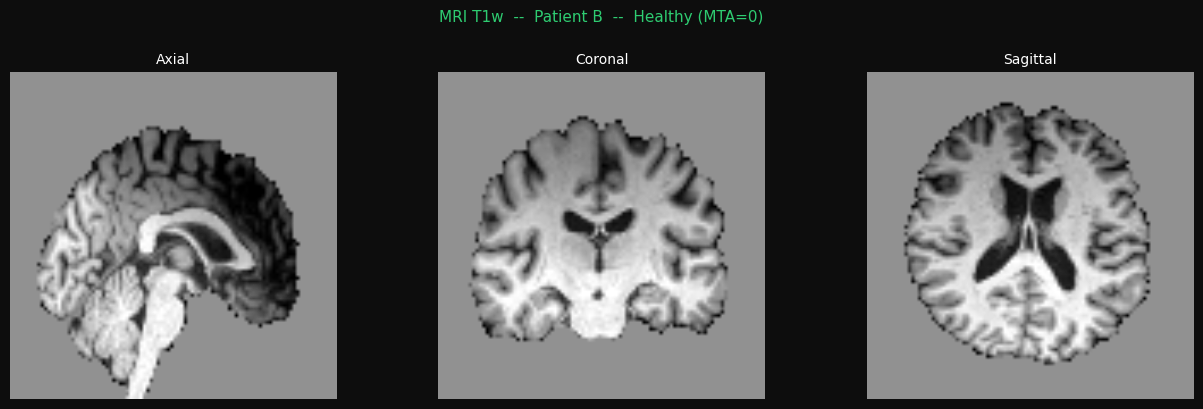


[PET] 7-fold amyloid ensemble ...
    POSITIVE (A+)  (prob=0.956  thr=0.503)


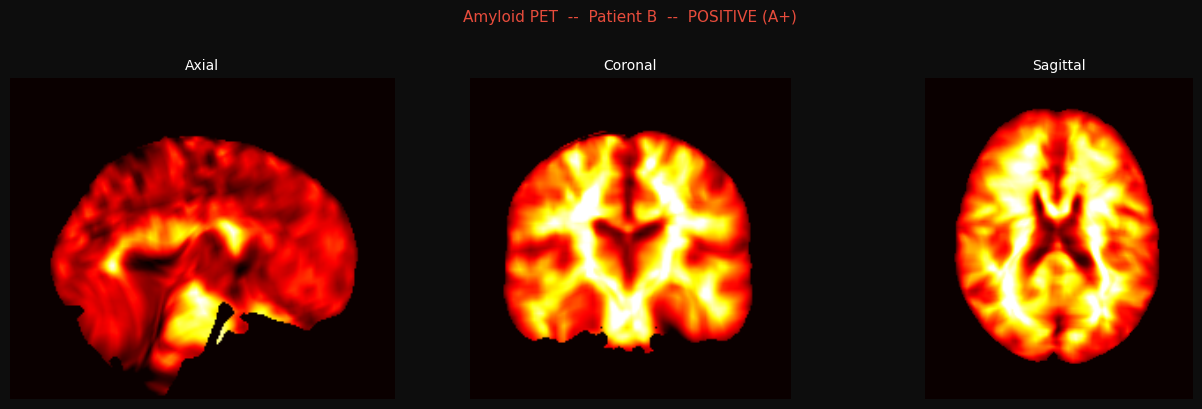


  Imaging inference complete for both patients.


In [25]:
# -- Step C: MRI + PET inference -- both patients --
import nibabel as nib
import concurrent.futures as cf

PREPROCESS_TIMEOUT_SEC = 300  # fall back to the pre-processed scan past this


def _run_with_timeout(fn, *args, timeout=PREPROCESS_TIMEOUT_SEC):
    with cf.ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(fn, *args)
        try:
            return fut.result(timeout=timeout), None
        except Exception as e:
            return None, e


def _load_mri_volume(mri_sub):
    raw_path = MRI_RAW_DIR / f"{mri_sub}.nii"
    if raw_path.exists():
        print(f"    Preprocessing raw MRI scan ({mri_sub}.nii) -- "
              f"N4 + HD-BET + ANTs registration, timeout={PREPROCESS_TIMEOUT_SEC}s ...")
        vol, err = _run_with_timeout(preprocess_mri_raw, raw_path)
        if vol is not None:
            print("    Raw preprocessing succeeded.")
            return vol
        print(f"    Raw preprocessing failed/timed out ({err}); "
              f"falling back to the pre-processed scan.")
    return np.load(MRI_IMAGE_DIR / f"{mri_sub}.npy").astype(np.float32)


def _load_pet_volume(pet_sub):
    raw_path = PET_RAW_DIR / f"{pet_sub}.nii"
    if raw_path.exists():
        print(f"    Preprocessing raw PET scan ({pet_sub}.nii) -- "
              f"smoothing + SyN registration + SUVR, timeout={PREPROCESS_TIMEOUT_SEC}s ...")
        vol, err = _run_with_timeout(preprocess_pet_raw, raw_path)
        if vol is not None:
            print("    Raw preprocessing succeeded.")
            return vol
        print(f"    Raw preprocessing failed/timed out ({err}); "
              f"falling back to the pre-processed scan.")
    return nib.load(str(PET_IMAGE_DIR / f"{pet_sub}.nii")).get_fdata(dtype=np.float32)


print("Pre-loading imaging volumes ...")
_mri_vols, _pet_vols = {}, {}
for s in state.values():
    mri_sub = s["pat"]["mri_sub"]
    pet_sub = s["pat"]["pet_sub"]
    if mri_sub and mri_sub not in _mri_vols:
        _mri_vols[mri_sub] = _load_mri_volume(mri_sub)
    if pet_sub and pet_sub not in _pet_vols:
        _pet_vols[pet_sub] = _load_pet_volume(pet_sub)
print(f"  {len(_mri_vols)} MRI volume(s), {len(_pet_vols)} PET volume(s) loaded.")

for label, s in state.items():
    pat, visits_df, last_idx = s["pat"], s["visits_df"], s["last_idx"]
    mri_sub, pet_sub = pat["mri_sub"], pat["pet_sub"]
    has_imaging = mri_sub is not None

    print(f"\n{'='*72}")
    print(f"  {label}")
    print(f"{'='*72}")

    # Demographics for imaging fusion branches: most recently stated value,
    # back/forward-filled across visits since they rarely change visit to visit.
    _demo = visits_df[["age", "PTGENDER", "PTEDUCAT"]].ffill().bfill()
    _age  = float(_demo["age"].iloc[-1])      if pd.notna(_demo["age"].iloc[-1])      else 0.0
    _ptg  = _demo["PTGENDER"].iloc[-1]
    _edu  = float(_demo["PTEDUCAT"].iloc[-1]) if pd.notna(_demo["PTEDUCAT"].iloc[-1]) else 0.0
    _gender_mri = 1.0 if _ptg == 1 else 0.0  # MRI training convention: M=1.0, F=0.0
    _sex_f_pet  = 0.0 if _ptg == 1 else 1.0  # PET training convention: F=1.0, M=0.0

    # ── MRI ──────────────────────────────────────────────────────────────────
    if has_imaging:
        print("\n[MRI] 7-fold atrophy ensemble ...")
        mri_atrophy, mri_avg, mri_thr = infer_mri(_mri_vols[mri_sub], _age, _gender_mri, _edu)
        mri_label = "ATROPHIC (MTA=1)" if mri_atrophy else "Healthy (MTA=0)"
        print(f"    {mri_label}  (prob={mri_avg:.3f}  thr={mri_thr:.3f})")

        vol = _mri_vols[mri_sub]
        mid = [d // 2 for d in vol.shape]
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor="#0d0d0d")
        for ax, (slc, ttl) in zip(axes, [
            (vol[mid[0], :, :], "Axial"),
            (vol[:, mid[1], :], "Coronal"),
            (vol[:, :, mid[2]], "Sagittal"),
        ]):
            ax.imshow(np.rot90(slc), cmap="gray", interpolation="bilinear")
            ax.set_title(ttl, color="white", fontsize=10)
            ax.axis("off")
        col_mri = "#e74c3c" if mri_atrophy else "#2ecc71"
        fig.suptitle(f"MRI T1w  --  {label}  --  {mri_label}", color=col_mri, fontsize=11, y=1.01)
        plt.tight_layout()
        plt.show()
        visits_df.loc[last_idx, "MTA_ATROPHY"] = mri_atrophy
    else:
        print("\n[MRI] no scan for this patient  (MTA_ATROPHY left unset)")
        mri_atrophy, mri_avg, mri_thr = 0, 0.0, 0.5

    # ── PET ──────────────────────────────────────────────────────────────────
    if has_imaging:
        print("\n[PET] 7-fold amyloid ensemble ...")
        amyloid_status, pet_avg, pet_thr = infer_pet(_pet_vols[pet_sub], _age, _sex_f_pet)
        pet_label = "POSITIVE (A+)" if amyloid_status else "Negative (A-)"
        print(f"    {pet_label}  (prob={pet_avg:.3f}  thr={pet_thr:.3f})")

        pvol = _pet_vols[pet_sub]
        pmid = [d // 2 for d in pvol.shape]
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor="#0d0d0d")
        for ax, (slc, ttl) in zip(axes, [
            (pvol[pmid[0], :, :], "Axial"),
            (pvol[:, pmid[1], :], "Coronal"),
            (pvol[:, :, pmid[2]], "Sagittal"),
        ]):
            ax.imshow(np.rot90(slc), cmap="hot", interpolation="bilinear", vmin=0.5, vmax=2.5)
            ax.set_title(ttl, color="white", fontsize=10)
            ax.axis("off")
        col_pet = "#e74c3c" if amyloid_status else "#2ecc71"
        fig.suptitle(f"Amyloid PET  --  {label}  --  {pet_label}", color=col_pet, fontsize=11, y=1.01)
        plt.tight_layout()
        plt.show()
        visits_df.loc[last_idx, "AMYLOID_STATUS"] = amyloid_status
    else:
        print("\n[PET] no scan for this patient  (AMYLOID_STATUS left unset)")
        amyloid_status, pet_avg, pet_thr = 0, 0.0, 0.5

    s["mri_atrophy"], s["mri_avg"], s["mri_thr"] = mri_atrophy, mri_avg, mri_thr
    s["amyloid_status"], s["pet_avg"], s["pet_thr"] = amyloid_status, pet_avg, pet_thr

print(f"\n{'='*72}")
print("  Imaging inference complete for both patients.")
print(f"{'='*72}")


## Step D — Diagnosis Classification: Both Patients, Every Visit

Runs the LightGBM and Neural Ensemble diagnosis classifiers independently on every visit row of both patients' tables (not just the current one), adding `DIAGNOSIS_LGB` / `DIAGNOSIS_ENS` columns.

In [26]:
# -- Step D: Diagnosis classification -- evaluated per visit, for both patients --
for label, s in state.items():
    print(f"\n[Diagnosis] {label}: LightGBM + Neural Ensemble, evaluated per visit ...")
    visits_df = s["visits_df"]
    diag_lgb_preds, diag_ens_preds = [], []
    for _, row in visits_df.iterrows():
        rec   = row.to_dict()
        d_lgb = predict_diagnosis(rec, diag_arts)
        d_ens = predict_diag_ensemble(rec, diag_arts, diag_neural_models)
        diag_lgb_preds.append(d_lgb["prediction"])
        diag_ens_preds.append(d_ens["prediction"])
    visits_df["DIAGNOSIS_LGB"] = diag_lgb_preds
    visits_df["DIAGNOSIS_ENS"] = diag_ens_preds
    s["diag_lgb"], s["diag_ens"] = d_lgb, d_ens
    print(f"    Current visit -> LightGBM: {d_lgb['prediction']}   "
          f"Neural Ensemble: {d_ens['prediction']}")

print(f"\n{'='*72}")
print("  Diagnosis classification complete for both patients.")
print(f"{'='*72}")



[Diagnosis] Patient A: LightGBM + Neural Ensemble, evaluated per visit ...
    Current visit -> LightGBM: MCI   Neural Ensemble: MCI

[Diagnosis] Patient B: LightGBM + Neural Ensemble, evaluated per visit ...
    Current visit -> LightGBM: Dementia   Neural Ensemble: MCI

  Diagnosis classification complete for both patients.


## Step E — Stability Classification: Both Patients

Runs the RNN and LightGBM stability classifiers once per patient on their full real visit trajectory, broadcasting `STABILITY_RNN` / `STABILITY_LGB` as constant columns across that patient's table.

In [27]:
# -- Step E: Stability classification -- on the real visit trajectory, for both patients --
for label, s in state.items():
    print(f"\n[Stability] {label}: RNN + LightGBM, evaluated on the full visit trajectory ...")
    visits_df     = s["visits_df"]
    visit_records = visits_df.to_dict("records")
    stab_rnn = predict_stability(visit_records, stab_arts, stab_model)
    stab_lgb = predict_stab_lightgbm(visit_records, stab_arts)
    visits_df["STABILITY_RNN"] = stab_rnn["prediction"]
    visits_df["STABILITY_LGB"] = stab_lgb["prediction"]
    s["stab_rnn"], s["stab_lgb"] = stab_rnn, stab_lgb
    print(f"    RNN: {stab_rnn['prediction']}   LightGBM: {stab_lgb['prediction']}")

print(f"\n{'='*72}")
print("  Stability classification complete for both patients.")
print(f"{'='*72}")



[Stability] Patient A: RNN + LightGBM, evaluated on the full visit trajectory ...
    RNN: MCI_stable   LightGBM: MCI_converting

[Stability] Patient B: RNN + LightGBM, evaluated on the full visit trajectory ...
    RNN: MCI_converting   LightGBM: MCI_converting

  Stability classification complete for both patients.


## Step F — Final Consolidated Tables: Both Patients

Prints the complete table (clinical history + imaging + per-visit diagnosis + stability) for each patient and populates `all_results`, which the summary panel below uses for the side-by-side comparison.

In [28]:
# -- Step F: Final consolidated tables -- both patients --
all_results = {}
for label, s in state.items():
    print(f"\n{'='*72}")
    print(f"  {label} -- Final Patient Table (clinical history + imaging + predictions)")
    print(f"{'='*72}")
    _final_df = s["visits_df"].drop(columns=["_month"])
    try:
        display(_final_df)
    except NameError:
        print(_final_df.to_string())

    all_results[label] = {
        "visits_df":      s["visits_df"],
        "mri_atrophy":    s["mri_atrophy"],    "mri_avg": s["mri_avg"],  "mri_thr": s["mri_thr"],
        "amyloid_status": s["amyloid_status"], "pet_avg": s["pet_avg"],  "pet_thr": s["pet_thr"],
        "diag_lgb":       s["diag_lgb"],
        "diag_ens":       s["diag_ens"],
        "stab_rnn":       s["stab_rnn"],
        "stab_lgb":       s["stab_lgb"],
    }

print(f"\n{'='*72}")
print("  Both patients processed.  Run the summary cell.")
print(f"{'='*72}")



  Patient A -- Final Patient Table (clinical history + imaging + predictions)


,RID,VISCODE2,age,PTGENDER,PTEDUCAT,PTHAND,PTMARRY,PTNOTRT,PTWORK,VISDATE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMREAD,MMWRITE,MMDRAW,MMREPEAT,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,WORD1,WORD2,WORD3,MMSCORE,MOCA,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,DIGFOR,DIGBACK,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,FAQFORM,FAQFINAN,FAQSHOP,FAQGAME,FAQBEVG,FAQMEAL,FAQEVENT,FAQTV,FAQREM,FAQTRAVL,FAQ,Abeta42,Abeta40,Abeta_ratio,Tau181,pTau181,Calcium,Creatinine,Direct Bilirubin,Gamma-Glutamyltransferase,Hematocrit,Hemoglobin,Hemoglobin A1C,Homocysteine,Platelet Ct.,Red Blood Cell Count,Thyroid-stimulating hormone,Total Bilirubin,Vitamin B12,White Blood Cell Count,glucose,MOTHDEM,MOTHAD,MOTHSXAGE,FATHDEM,FATHAD,FATHSXAGE,SIBGENDER,SIBDEMENT,SIBAD,SIBSXAGE,IHSYMPTOM,IHDESC,IHCHRON,IHSEVER,IHPRESENT,IHSURG,MH19OTHR,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH14BALCH,MH14CALCH,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH17MALI,MH18SURG,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,BSXSYMNO,BSXSEVER,BSXCHRON,KEYMED,CMMED,CMDOSE,CMREASON,MTA_ATROPHY,AMYLOID_STATUS,VISCODE2_num,VISDATE_days,DIAGNOSIS_LGB,DIAGNOSIS_ENS,STABILITY_RNN,STABILITY_LGB
0,1,bl,None,None,None,None,None,None,None,2005-08-18,None,None,None,None,None,None,0.0,None,None,None,None,None,1.0,1.0,1.0,27,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,0,0,0,0,0,0,0,0,0,0,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Atorvastatine,20 mg/jour,2,NaN,NaN,0.0,0.0,CN,MCI,MCI_stable,MCI_converting
1,1,m01,None,None,None,None,None,None,None,2005-09-08,None,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,27,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,0,0,0,0,0,0,0,0,0,0,1501.0,None,None,153.4,13.29,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Paracétamol,2 x 500 mg/j,2,NaN,NaN,1.0,21.0,CN,MCI,MCI_stable,MCI_converting
2,1,m08,None,None,None,None,None,None,None,2006-05-02,None,None,None,None,None,None,1.0,None,None,None,None,None,NaN,NaN,NaN,20,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,0,0,0,0,0,0,0,0,0,0,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Vitamine E,400 IU,2,NaN,NaN,8.0,257.0,MCI,MCI,MCI_stable,MCI_converting
3,1,m15,None,None,None,None,None,None,None,2006-11-28,None,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,26,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,1,1,0,0,0,0,0,0,0,3,246.0,None,None,49.4,13.50,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0,None,None,2,None,None,None,None,None,None,0,Atorvastatine,40 mg/jour,2,NaN,NaN,15.0,467.0,MCI,MCI,MCI_stable,MCI_converting
4,1,m21,None,None,None,None,None,None,None,2007-05-14,None,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,27,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,1,1,0,0,0,0,0,0,0,0,1,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None


  Patient B -- Final Patient Table (clinical history + imaging + predictions)


,RID,VISCODE2,age,PTGENDER,PTEDUCAT,PTHAND,PTMARRY,PTNOTRT,PTWORK,VISDATE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMREAD,MMWRITE,MMDRAW,MMREPEAT,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,WORD1,WORD2,WORD3,MMSCORE,MOCA,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,DIGFOR,DIGBACK,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,FAQFORM,FAQFINAN,FAQSHOP,FAQGAME,FAQBEVG,FAQMEAL,FAQEVENT,FAQTV,FAQREM,FAQTRAVL,FAQ,Abeta42,Abeta40,Abeta_ratio,Tau181,pTau181,Calcium,Creatinine,Direct Bilirubin,Gamma-Glutamyltransferase,Hematocrit,Hemoglobin,Hemoglobin A1C,Homocysteine,Platelet Ct.,Red Blood Cell Count,Thyroid-stimulating hormone,Total Bilirubin,Vitamin B12,White Blood Cell Count,glucose,MOTHDEM,MOTHAD,MOTHSXAGE,FATHDEM,FATHAD,FATHSXAGE,SIBGENDER,SIBDEMENT,SIBAD,SIBSXAGE,IHSYMPTOM,IHDESC,IHCHRON,IHSEVER,IHPRESENT,IHSURG,MH19OTHR,MHPSYCH,MH2NEURL,MH3HEAD,MH4CARD,MH5RESP,MH6HEPAT,MH7DERM,MH8MUSCL,MH9ENDO,MH14BALCH,MH14CALCH,MH10GAST,MH11HEMA,MH12RENA,MH13ALLE,MH14ALCH,MH14AALCH,MH17MALI,MH18SURG,MH15DRUG,MH15ADRUG,MH15BDRUG,MH16SMOK,MH16ASMOK,MH16BSMOK,MH16CSMOK,BSXSYMNO,BSXSEVER,BSXCHRON,KEYMED,CMMED,CMDOSE,CMREASON,MTA_ATROPHY,AMYLOID_STATUS,VISCODE2_num,VISDATE_days,DIAGNOSIS_LGB,DIAGNOSIS_ENS,STABILITY_RNN,STABILITY_LGB
0,2,bl,61.0,None,14,1,1,NaN,None,2012-04-30,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Aspirine,81 mg/j,2,NaN,NaN,0.0,0.0,CN,MCI,MCI_converting,MCI_converting
1,2,m01,61.0,None,14,1,1,NaN,None,2012-05-16,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30,None,NaN,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,1397.0,220.58,0.03272,261.3,23.34,None,None,None,None,None,None,None,None,None,None,None,None,None,None,51.0,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Aspirine,81 mg/j,2,NaN,NaN,1.0,16.0,MCI,MCI,MCI_converting,MCI_converting
2,2,m03,NaN,None,14,1,1,NaN,None,2012-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Lynothyrox,45,2,NaN,NaN,3.0,94.0,MCI,MCI,MCI_converting,MCI_converting
3,2,m03,62.0,None,14,1,1,NaN,None,2012-08-05,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,28,None,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,0,Lynothyrox,100,2,NaN,NaN,3.0,97.0,MCI,MCI,MCI_converting,MCI_converting
4,2,m13,63.0,None,14,1,1,0.0,None,2013-05-18,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26,None,1.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,2.0,16.0,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,0,0,None,0,0,None,None,0,0,None,None,None,None,None,None,None,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,None,0,0,0,None,None,None,None,None,None,None,None,None,6,Sertraline,50 mg/j,2,0.0,1.0,13.0,383.0,Dementia,MCI,MCI_converting,MCI_converting



  Both patients processed.  Run the summary cell.


## Final Results — All Models, Both Patients

Renders the side-by-side comparison panel for both patients showing:
MRI atrophy, PET amyloid, key clinical scores, and the predictions from
all four models (LightGBM diagnosis, Neural Ensemble diagnosis,
RNN stability, LightGBM stability). Also saves `demo_comparison.png`.


  Patient A  (Age: N/A, Sex: N/A)
  MRI           -> Healthy (MTA=0)
  PET           -> Amyloid NEGATIVE (A-)
  DIAG LightGBM -> MCI  (p=0.547)
  DIAG Ensemble -> MCI  (p=0.705)  members=['GRNNet', 'DeepResNet-SE', 'DualStreamDomainNet']
  STAB RNN      -> MCI_stable  (p=0.634)
  STAB LightGBM -> MCI_converting  (p=0.667)

  Patient B  (Age: 63.0, Sex: N/A)
  MRI           -> Healthy (MTA=0)
  PET           -> Amyloid POSITIVE (A+)
  DIAG LightGBM -> Dementia  (p=0.769)
  DIAG Ensemble -> MCI  (p=0.497)  members=['GRNNet', 'DeepResNet-SE', 'DualStreamDomainNet']
  STAB RNN      -> MCI_converting  (p=0.552)
  STAB LightGBM -> MCI_converting  (p=0.872)


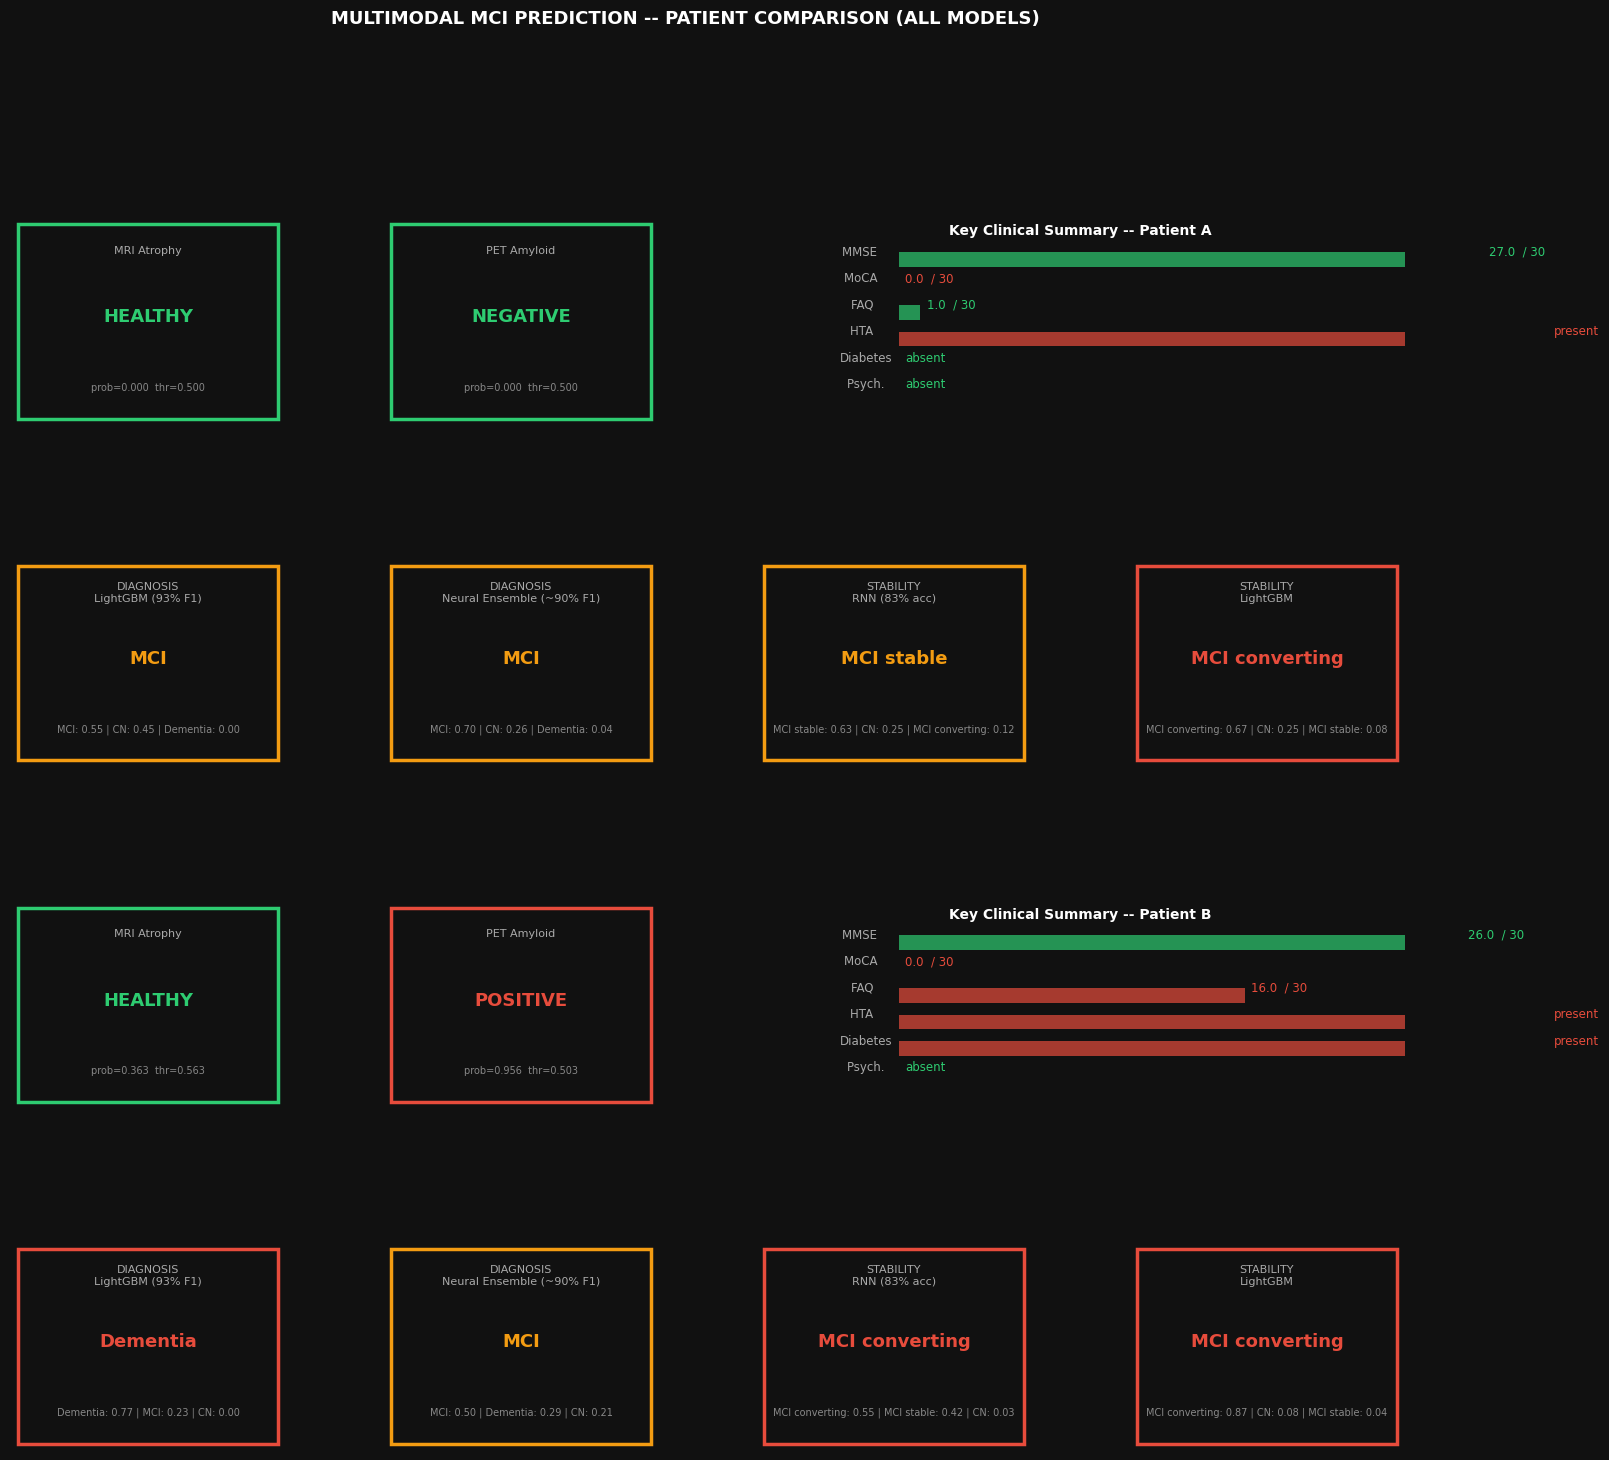

In [29]:
# -- Side-by-side comparison: both patients, all models --
n_pat = len(all_results)
fig   = plt.figure(figsize=(18, 8 * n_pat), facecolor='#111111')
gs    = gridspec.GridSpec(n_pat * 2, 4, figure=fig, hspace=0.65, wspace=0.35)

COLOR_OK   = "#2ecc71"
COLOR_BAD  = "#e74c3c"
COLOR_WARN = "#f39c12"
COLOR_NEU  = "#3498db"
COLOR_PRP  = "#9b59b6"


def add_result_box(ax, title, value, subtitle="", color=COLOR_NEU):
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.add_patch(plt.Rectangle((0.03, 0.03), 0.94, 0.94, fill=False,
                                edgecolor=color, linewidth=2.5, transform=ax.transAxes))
    ax.text(0.5, 0.84, title, ha='center', va='center', fontsize=8,
            color='#aaaaaa', transform=ax.transAxes)
    ax.text(0.5, 0.52, value, ha='center', va='center', fontsize=13,
            color=color, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.18, subtitle, ha='center', va='center', fontsize=7,
            color='#888888', transform=ax.transAxes, wrap=True)


for row_i, (label, res) in enumerate(all_results.items()):
    pr      = res["visits_df"].iloc[-1].to_dict()
    mri_a   = res["mri_atrophy"];    m_avg = res["mri_avg"]; m_thr = res["mri_thr"]
    amy     = res["amyloid_status"]; p_avg = res["pet_avg"]; p_thr = res["pet_thr"]
    d_lgb   = res["diag_lgb"];   d_ens = res["diag_ens"]
    s_rnn   = res["stab_rnn"];   s_lgb = res["stab_lgb"]
    base    = row_i * 2

    # Row 0: MRI | PET | Clinical summary
    ax_mri = fig.add_subplot(gs[base, 0])
    add_result_box(ax_mri, "MRI Atrophy",
                   "ATROPHIC" if mri_a else "HEALTHY",
                   f"prob={m_avg:.3f}  thr={m_thr:.3f}",
                   COLOR_BAD if mri_a else COLOR_OK)

    ax_pet = fig.add_subplot(gs[base, 1])
    add_result_box(ax_pet, "PET Amyloid",
                   "POSITIVE" if amy else "NEGATIVE",
                   f"prob={p_avg:.3f}  thr={p_thr:.3f}",
                   COLOR_BAD if amy else COLOR_OK)

    ax_clin = fig.add_subplot(gs[base, 2:])
    ax_clin.set_facecolor('#1a1a2e'); ax_clin.axis('off')
    _mmse = float(pr.get("MMSCORE") or 0)
    _moca = float(pr.get("MOCA")    or 0)
    _faq  = float(pr.get("FAQ")     or 0)
    _mh4  = float(pr.get("MH4CARD") or 0)
    _mh9  = float(pr.get("MH9ENDO") or 0)
    _mhps = float(pr.get("MHPSYCH") or 0)
    clinical_items = [
        ("MMSE",     _mmse, 30, 24,  "/ 30", True),
        ("MoCA",     _moca, 30, 26,  "/ 30", True),
        ("FAQ",      _faq,  30,  5,  "/ 30", False),
        ("HTA",      _mh4,   1, 0.5, "flag", False),
        ("Diabetes", _mh9,   1, 0.5, "flag", False),
        ("Psych.",   _mhps,  1, 0.5, "flag", False),
    ]
    ax_clin.text(0.5, 0.97, f"Key Clinical Summary -- {label}", ha='center', va='top',
                 color='white', fontsize=10, fontweight='bold', transform=ax_clin.transAxes)
    for i, (name, val, max_v, thr, unit, low_bad) in enumerate(clinical_items):
        y = 0.80 - i * 0.128
        abnormal = (val < thr) if low_bad else (val > thr)
        c = COLOR_BAD if abnormal else COLOR_OK
        frac = min(val / max_v, 1.0) if max_v else 0
        ax_clin.barh(y, frac, height=0.07, left=0.22, color=c, alpha=0.7,
                     transform=ax_clin.transAxes)
        ax_clin.text(0.21, y + 0.035, f"{name:8s}", ha='right', va='center',
                     color='#aaaaaa', fontsize=8.5, transform=ax_clin.transAxes)
        lbl = ("present" if val >= 1 else "absent") if unit == "flag" else f"{val:.1f}  {unit}"
        ax_clin.text(0.22 + frac + 0.01, y + 0.035, lbl, ha='left', va='center',
                     color=c, fontsize=8.5, transform=ax_clin.transAxes)

    # Row 1: 4 prediction boxes
    def _pred_col(pred, mapping):
        return mapping.get(pred, COLOR_NEU)

    diag_map = {"MCI": COLOR_WARN, "CN": COLOR_OK, "Dementia": COLOR_BAD}
    stab_map = {"MCI_converting": COLOR_BAD, "CN": COLOR_OK, "MCI_stable": COLOR_WARN}

    # Diagnosis LightGBM
    ax0 = fig.add_subplot(gs[base + 1, 0])
    d0s = sorted(d_lgb["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax0, "DIAGNOSIS\nLightGBM (93% F1)",
                   d_lgb["prediction"],
                   " | ".join(f"{c}: {p:.2f}" for c, p in d0s),
                   _pred_col(d_lgb["prediction"], diag_map))

    # Diagnosis Neural Ensemble
    ax1 = fig.add_subplot(gs[base + 1, 1])
    d1s = sorted(d_ens["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax1, "DIAGNOSIS\nNeural Ensemble (~90% F1)",
                   d_ens["prediction"],
                   " | ".join(f"{c}: {p:.2f}" for c, p in d1s),
                   _pred_col(d_ens["prediction"], diag_map))

    # Stability RNN
    ax2 = fig.add_subplot(gs[base + 1, 2])
    s0s = sorted(s_rnn["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax2, "STABILITY\nRNN (83% acc)",
                   s_rnn["prediction"].replace("_", " "),
                   " | ".join(f"{c.replace('_',' ')}: {p:.2f}" for c, p in s0s),
                   _pred_col(s_rnn["prediction"], stab_map))

    # Stability LightGBM
    ax3 = fig.add_subplot(gs[base + 1, 3])
    s1s = sorted(s_lgb["probabilities"].items(), key=lambda x: -x[1])
    add_result_box(ax3, "STABILITY\nLightGBM",
                   s_lgb["prediction"].replace("_", " "),
                   " | ".join(f"{c.replace('_',' ')}: {p:.2f}" for c, p in s1s),
                   _pred_col(s_lgb["prediction"], stab_map))

    # Text summary
    age_d = pr.get("age") or "N/A"; sex_d = pr.get("PTGENDER") or "N/A"
    print(f"\n{'='*68}")
    print(f"  {label}  (Age: {age_d}, Sex: {sex_d})")
    print(f"{'='*68}")
    print(f"  MRI           -> {'Atrophic (MTA=1)' if mri_a else 'Healthy (MTA=0)'}")
    print(f"  PET           -> {'Amyloid POSITIVE (A+)' if amy else 'Amyloid NEGATIVE (A-)'}")
    print(f"  DIAG LightGBM -> {d_lgb['prediction']}  "
          f"(p={max(p for _,p in d0s):.3f})")
    print(f"  DIAG Ensemble -> {d_ens['prediction']}  "
          f"(p={max(p for _,p in d1s):.3f})"
          f"  members={d_ens['ensemble_members']}")
    print(f"  STAB RNN      -> {s_rnn['prediction']}  "
          f"(p={max(p for _,p in s0s):.3f})")
    print(f"  STAB LightGBM -> {s_lgb['prediction']}  "
          f"(p={max(p for _,p in s1s):.3f})")

fig.suptitle("MULTIMODAL MCI PREDICTION -- PATIENT COMPARISON (ALL MODELS)",
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.savefig("demo_comparison.png", dpi=120, bbox_inches='tight', facecolor='#111111')
plt.show()
